In [1]:
import matplotlib
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import glob
import os

from src.OrganoidMesh import OrganoidMesh
from src.mesh_analysis import *
from src.nonlocal_correlations import *
from src.cell_graph_functions import *
from src.utils import *

In [2]:
import networkx as nx
import numpy as np

def load_cell_graph_from_npz(data: np.lib.npyio.NpzFile) -> nx.Graph:
    """
    Reconstruct a NetworkX graph from edges and node count stored in an NPZ file.
    This matches the new preprocessing format where `edges` and `n_nodes`
    are explicitly saved.
    """
    if "graph_edges" not in data.files or "graph_n_nodes" not in data.files:
        raise KeyError("NPZ file must contain 'edges' and 'n_nodes' to load the cell graph.")

    edges = data["graph_edges"]
    n_nodes = int(data["graph_n_nodes"])

    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))

    if edges.size > 0:
        edges = edges.reshape(-1, 2)
        G.add_edges_from(edges.tolist())

    return G


## Load pre-processed organoids

In [3]:
dmax = 20
nbins = 32
bin_edges = np.linspace(0.0, dmax, nbins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

n_perms = 999
k_value = 1

In [4]:
import pandas as pd
import numpy as np
import os, glob
from tqdm import tqdm

# -----------------------------------------
# Load complexity scores from tsne_results.csv
# -----------------------------------------
tsne_df = pd.read_csv("../NicoleData/tsne_results.csv")
# Expecting columns: label_uid (e.g. "day3p5_A01_42"), ..., complexity (4th column)
complexity_dict = dict(zip(tsne_df["label_uid"], tsne_df["complexity"]))

print(f"Loaded {len(complexity_dict)} complexity scores")

# Base directory for preprocessed data
preproc_base = os.path.join('..', 'NicoleData', 'preprocessed')

# --- Discover available timepoints dynamically ---
timepoints = sorted(
    [d for d in os.listdir(preproc_base) if os.path.isdir(os.path.join(preproc_base, d))]
)
print(f"Found {len(timepoints)} timepoints: {timepoints}")

# --- Specify target source markers (subset of marker_names) ---
target_source_markers = ["Serotonin", "Lysozyme", "LGR5"]

# --- Initialize global container ---
results = {}

for tp in timepoints:
    print(f"\n=== Analyzing timepoint: {tp} ===")

    tp_dir = os.path.join(preproc_base, tp)
    npz_files = sorted(glob.glob(os.path.join(tp_dir, "*.npz")))
    if not npz_files:
        print(f"  ⚠ No .npz files found for {tp}, skipping.")
        continue

    # --- Per-timepoint containers ---
    Corr_all_list = []
    Corr_conn_all_list = []
    Enrichment_all_list = []
    F_local_all_list = []
    F_global_all_list = []
    Ns_enrich_all_list = []
    hks_profile_all = []

    num_cells_list = []
    total_area_list = []
    total_volume_list = []

    hks_cell_mean_list = []
    hks_cell_std_list = []

    global_I_list = []
    global_perm_list = []

    knn_avg_list = []
    knn_std_list = []
    knn_sem_list = []
    knn_count_list = []

    complexity_list = [] 

    # --- Loop over organoids ---
    for fpath in tqdm(npz_files, desc=f"{tp}"):
        try:
            data = np.load(fpath, allow_pickle=True)
        except Exception as e:
            print(f"Could not load {fpath}: {e}")
            continue

        try:
            fields_cell = data["fields_cell"]
            markers_cell = data["markers_cell"]
            cell_areas = data["cell_areas"]
            dist_heat = data["dist_heat"]
            cell_graph = load_cell_graph_from_npz(data)
            marker_names = list(data["marker_names"])

            num_markers = markers_cell.shape[1]
            num_cells = len(cell_areas)
            total_area = np.sum(data["vertex_areas"])
            total_volume = float(data["volume"])

            num_cells_list.append(num_cells)
            total_area_list.append(total_area)
            total_volume_list.append(total_volume)

            # ---------- Complexity ----------
            well = str(data["well"])
            organoid_id = str(data["organoid_id"])
            label_uid = f"{tp}_{well}_{organoid_id}"

            complexity_value = complexity_dict.get(label_uid, np.nan)
            complexity_list.append(complexity_value)

            # ---------- Correlations ----------
            bins_dist = pair_bins_by_distance(dist_heat, cell_areas, bin_edges, use_area_weights=False)
            Corr, Corr_conn, _, _ = compute_two_point_correlations(bins_dist, fields_cell)
            Corr_all_list.append(Corr)
            Corr_conn_all_list.append(Corr_conn)

            # ---------- Enrichment + anchored HKS ----------
            positive_indices, positive_labels = positive_indices_and_labels(markers_cell)
            fields_centered = fields_cell - fields_cell.mean(axis=0, keepdims=True)

            hks_cell_mean, hks_cell_std, _ = local_field_statistics(fields_centered, positive_labels)
            hks_cell_mean_list.append(hks_cell_mean)
            hks_cell_std_list.append(hks_cell_std)

            enrichment_per_organoid = np.zeros((num_markers, len(bin_centers), num_markers))
            f_local_per_organoid = np.zeros_like(enrichment_per_organoid)
            f_global_per_organoid = np.zeros((num_markers, num_markers))
            Ns_per_organoid = np.zeros(len(bin_centers))

            n_fields = fields_centered.shape[1]
            hks_profile_per_organoid = np.zeros((num_markers, len(bin_centers), n_fields))

            source_indices = [
                marker_names.index(m)
                for m in target_source_markers
                if m in marker_names
            ]
            if len(source_indices) == 0:
                Enrichment_all_list.append(np.full_like(enrichment_per_organoid, np.nan))
                F_local_all_list.append(np.full_like(f_local_per_organoid, np.nan))
                F_global_all_list.append(np.full_like(f_global_per_organoid, np.nan))
                Ns_enrich_all_list.append(np.full_like(Ns_per_organoid, np.nan))
                hks_profile_all.append(np.full_like(hks_profile_per_organoid, np.nan))
            else:
                for m_idx in source_indices:
                    seeds = positive_indices[m_idx]
                    if len(seeds) == 0:
                        enrichment_per_organoid[m_idx, :, :] = np.nan
                        f_local_per_organoid[m_idx, :, :] = np.nan
                        f_global_per_organoid[m_idx, :] = np.nan
                        hks_profile_per_organoid[m_idx, :, :] = np.nan
                        continue

                    bins_sources = pair_bins_by_distance(
                        dist_heat, cell_areas, bin_edges, sources=seeds, use_area_weights=False
                    )
                    enrichment, f_local, f_global, Ns_bin = compute_anchored_enrichment(bins_sources, positive_labels)
                    hks_profile, _ = compute_anchored_radial_profile(bins_sources, fields_centered)

                    enrichment_per_organoid[m_idx, :, :] = enrichment
                    f_local_per_organoid[m_idx, :, :] = f_local
                    f_global_per_organoid[m_idx, :] = f_global
                    Ns_per_organoid = Ns_bin
                    hks_profile_per_organoid[m_idx, :, :] = hks_profile

                Enrichment_all_list.append(enrichment_per_organoid)
                F_local_all_list.append(f_local_per_organoid)
                F_global_all_list.append(f_global_per_organoid)
                Ns_enrich_all_list.append(Ns_per_organoid)
                hks_profile_all.append(hks_profile_per_organoid)

            # ---------- Moran's I ----------
            if len(source_indices) > 0:
                W, nodes = build_weight_matrix_kNN(cell_graph, k=k_value, row_standardize=False)
                global_I_obs, local_I_obs, global_I_perm, p_values = permutation_test_morans_I(
                    positive_labels, W, Y=positive_labels, n_perms=n_perms
                )

                full_obs = np.full((num_markers, num_markers), np.nan)
                full_perm = np.full((n_perms, num_markers, num_markers), np.nan)
                for m_idx in range(num_markers):
                    full_obs[m_idx, :] = global_I_obs[m_idx, :]
                    full_perm[:, m_idx, :] = global_I_perm[:, m_idx, :]
                global_I_list.append(full_obs)
                global_perm_list.append(full_perm)

            # ---------- kNN marker composition ----------
            knn_avg  = np.full((num_markers, num_markers), np.nan)
            knn_std  = np.full((num_markers, num_markers), np.nan)
            knn_sem  = np.full((num_markers, num_markers), np.nan)
            knn_count = np.zeros((num_markers,), dtype=int)

            for focal_idx in source_indices:
                try:
                    avg_comp, std_comp, sem_comp, comp_accum = kNN_marker_composition(
                        cell_graph, positive_labels, focal_marker_idx=focal_idx, k=k_value
                    )
                    knn_avg[focal_idx, :] = avg_comp
                    knn_std[focal_idx, :] = std_comp
                    knn_sem[focal_idx, :] = sem_comp
                    knn_count[focal_idx]  = comp_accum.shape[0]
                except ValueError:
                    continue

            knn_avg_list.append(knn_avg)
            knn_std_list.append(knn_std)
            knn_sem_list.append(knn_sem)
            knn_count_list.append(knn_count)

        except Exception as e:
            print(f"Error in analysing {fpath}: {e}")
            continue

    # ---------- Postprocessing ----------
    if len(global_I_list) > 0:
        global_I_array = np.stack(global_I_list, axis=0)
    else:
        global_I_array = np.empty((0, num_markers, num_markers))

    if len(global_perm_list) > 0:
        global_perm_array = np.stack(global_perm_list, axis=0)
    else:
        global_perm_array = np.empty((0, n_perms, num_markers, num_markers))

    if global_I_array.size > 0:
        ensemble_global_I_mean = np.nanmean(global_I_array, axis=0)
    else:
        ensemble_global_I_mean = np.full((num_markers, num_markers), np.nan)

    if global_perm_array.size > 0:
        perm_all = np.concatenate(global_perm_array, axis=0)
        p_val = np.mean(np.abs(perm_all) >= np.abs(ensemble_global_I_mean[None, :, :]), axis=0)
    else:
        perm_all = np.empty((0, n_perms, num_markers, num_markers))
        p_val = np.full((num_markers, num_markers), np.nan)

    # ---------- Stack results ----------
    results[tp] = {
        # Existing fields...
        'Corr_all': np.stack(Corr_all_list, axis=0),
        'Corr_conn_all': np.stack(Corr_conn_all_list, axis=0),
        'Enrichment_all': np.stack(Enrichment_all_list, axis=0),
        'F_local_all': np.stack(F_local_all_list, axis=0),
        'F_global_all': np.stack(F_global_all_list, axis=0),
        'Ns_enrich_all': np.stack(Ns_enrich_all_list, axis=0),
        'hks_profile_all': np.stack(hks_profile_all, axis=0),
        'hks_cell_mean_all': np.stack(hks_cell_mean_list, axis=0),
        'hks_cell_std_all': np.stack(hks_cell_std_list, axis=0),

        'global_I_ensemble': global_I_array,
        'global_perm_ensemble': global_perm_array,
        'ensemble_global_I_mean': ensemble_global_I_mean,
        'ensemble_global_perm': perm_all,
        'ensemble_p_values': p_val,

        'num_cells': np.array(num_cells_list),
        'total_area': np.array(total_area_list),
        'total_volume': np.array(total_volume_list),

        'knn_avg_all': np.stack(knn_avg_list, axis=0),
        'knn_std_all': np.stack(knn_std_list, axis=0),
        'knn_sem_all': np.stack(knn_sem_list, axis=0),
        'knn_count_all': np.stack(knn_count_list, axis=0),

        'complexity': np.array(complexity_list),
    }

    print(f"Processed {len(Corr_all_list)} organoids at {tp}")


Loaded 2668 complexity scores
Found 6 timepoints: ['day3', 'day3p5', 'day3p5-selected', 'day4', 'day4p5', 'day4p5-more']

=== Analyzing timepoint: day3 ===


day3:   0%|          | 0/472 [00:00<?, ?it/s]/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/src/cell_graph_functions.py:308: RuntimeWarning: invalid value encountered in divide
  global_I = (N / S0) * (Z_X.T @ W @ Z_Y) / np.sum(Z_X**2, axis=0)[:, None]
/home/fmoller/Projects/LearningOrganoids/SphericalHarmonics/src/cell_graph_functions.py:310: RuntimeWarning: invalid value encountered in divide
  local_I = (Z_X[:, :, None] / m2_X[None, :, None]) * WZ_Y[:, None, :]
day3: 100%|██████████| 472/472 [00:20<00:00, 23.01it/s]


Processed 472 organoids at day3

=== Analyzing timepoint: day3p5 ===


day3p5: 100%|██████████| 312/312 [00:26<00:00, 11.64it/s]


Processed 312 organoids at day3p5

=== Analyzing timepoint: day3p5-selected ===


...

Processed 109 organoids at day4p5

=== Analyzing timepoint: day4p5-more ===


day4p5-more:  66%|██████▌   | 350/534 [01:16<00:34,  5.35it/s]

Error in analysing ../NicoleData/preprocessed/day4p5-more/413.npz: Total weight is zero — check bins_dict or fields.


day4p5-more: 100%|██████████| 534/534 [01:48<00:00,  4.92it/s]


Processed 533 organoids at day4p5-more


In [5]:

# --- Define binning parameters ---
cell_bin_start = 0
cell_bin_end = 600    # up to this number, will also add np.inf
cell_bin_step = 100

# --- Generate bin edges as a numpy array ---
cell_number_bins = np.arange(cell_bin_start, cell_bin_end + cell_bin_step, cell_bin_step)
cell_number_bins = np.append(cell_number_bins, np.inf)   # final open-ended bin

# --- Create bin labels ---
bin_labels = [
    f"{int(cell_number_bins[i])}–{int(cell_number_bins[i+1]-1)}"
    if np.isfinite(cell_number_bins[i+1])
    else f"{int(cell_number_bins[i])}+"
    for i in range(len(cell_number_bins)-1)
]

print("Cell number bins:", cell_number_bins)
print("Bin labels:", bin_labels)

# -----------------------------------------------------------------
# Gather all organoids across timepoints and bin by cell number
# -----------------------------------------------------------------

# We'll store a list of (tp, idx) for each bin
binned_organoids_by_cellnum = {label: [] for label in bin_labels}
all_num_cells = []

for tp in results.keys():
    num_cells_arr = results[tp]['num_cells']
    all_num_cells.extend(num_cells_arr)

    bin_indices = np.digitize(num_cells_arr, cell_number_bins) - 1  # 0-based
    for org_idx, b_idx in enumerate(bin_indices):
        binned_organoids_by_cellnum[bin_labels[b_idx]].append((tp, org_idx))


Cell number bins: [  0. 100. 200. 300. 400. 500. 600.  inf]
Bin labels: ['0–99', '100–199', '200–299', '300–399', '400–499', '500–599', '600+']


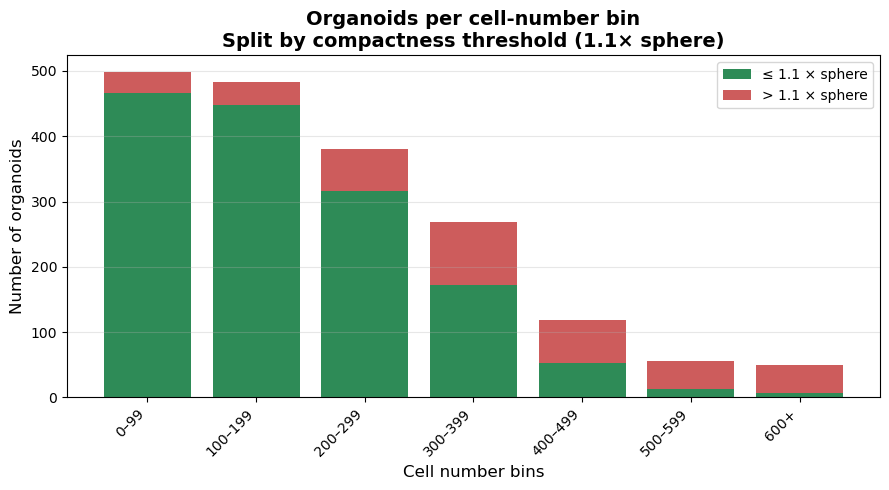

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Threshold for compactness relative to sphere
threshold = 1.1
comp_sphere = 4.835

# Initialize counts per bin
below_counts = []
above_counts = []
total_counts = []

for label in bin_labels:
    entries = binned_organoids_by_cellnum[label]
    n_total = len(entries)
    total_counts.append(n_total)
    if n_total == 0:
        below_counts.append(0)
        above_counts.append(0)
        continue

    compactness_vals = []
    for tp, org_idx in entries:
        area = results[tp]['total_area'][org_idx]
        volume = results[tp]['total_volume'][org_idx]
        comp = area / (volume ** (2.0 / 3.0)) / comp_sphere
        compactness_vals.append(comp)

    compactness_vals = np.array(compactness_vals)
    n_below = np.sum(compactness_vals <= threshold)
    n_above = np.sum(compactness_vals > threshold)

    below_counts.append(n_below)
    above_counts.append(n_above)

# Convert to arrays for plotting
below_counts = np.array(below_counts)
above_counts = np.array(above_counts)
total_counts = np.array(total_counts)

# -----------------------------------------------------------------
# Stacked bar plot (absolute counts, split by threshold)
# -----------------------------------------------------------------
plt.figure(figsize=(9, 5))

bar_width = 0.8
x = np.arange(len(bin_labels))

plt.bar(x, below_counts, width=bar_width, color='seagreen', label=f"≤ {threshold:.1f} × sphere")
plt.bar(x, above_counts, width=bar_width, bottom=below_counts, color='indianred', label=f"> {threshold:.1f} × sphere")

plt.xticks(x, bin_labels, rotation=45, ha='right')
plt.ylabel("Number of organoids", fontsize=12)
plt.xlabel("Cell number bins", fontsize=12)
plt.title(f"Organoids per cell-number bin\nSplit by compactness threshold ({threshold:.1f}× sphere)", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


/tmp/ipykernel_11140/980038680.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_time = get_cmap('tab10')  # timepoints (categorical)
/tmp/ipykernel_11140/980038680.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_bins = get_cmap('viridis')  # cell-number bins (ordered)


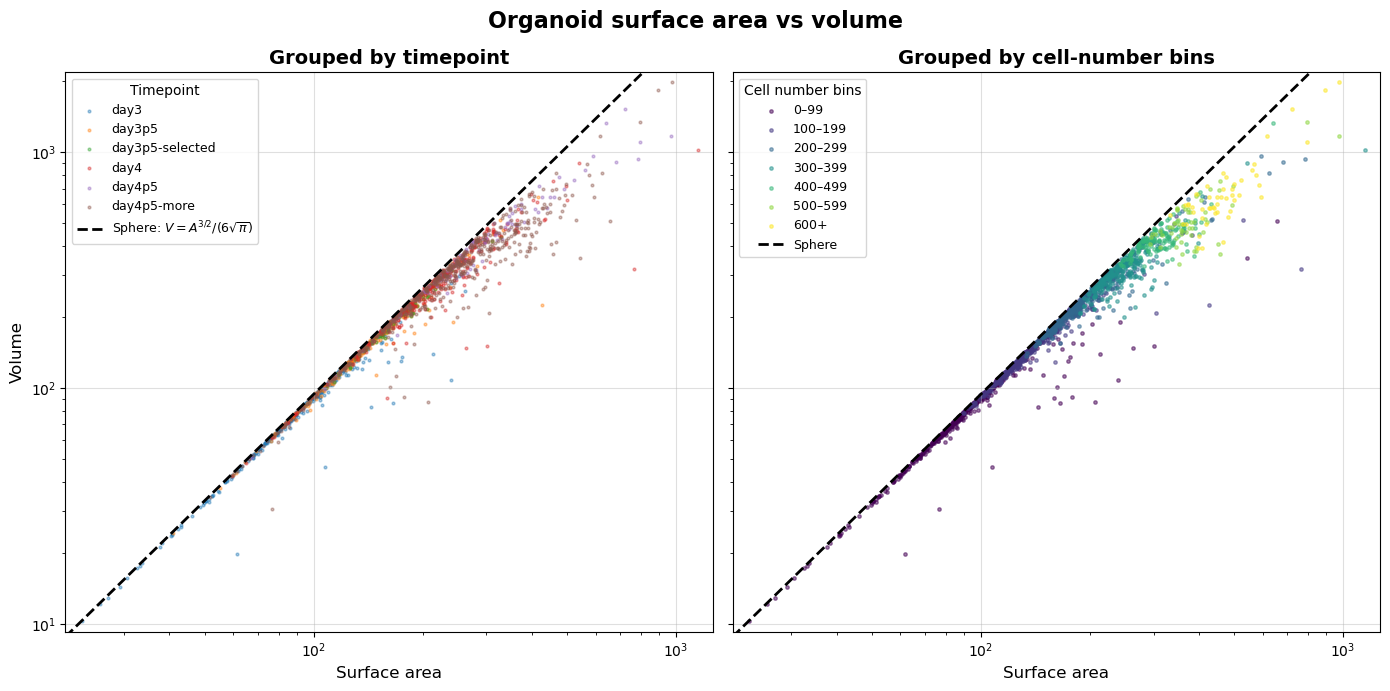

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import get_cmap

# --- Prepare color maps ---
cmap_time = get_cmap('tab10')  # timepoints (categorical)
colors_time = {tp: cmap_time(i % 10) for i, tp in enumerate(timepoints)}

cmap_bins = get_cmap('viridis')  # cell-number bins (ordered)
colors_bins = {label: cmap_bins(i / max(1, len(bin_labels)-1)) for i, label in enumerate(bin_labels)}

# --- Create figure with 2 subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)

# =====================================================
# 1️⃣ Left subplot — grouped by timepoint
# =====================================================
ax = axes[0]
for tp in timepoints:
    res = results[tp]
    areas = res['total_area']
    volumes = res['total_volume']
    ax.scatter(
        areas, volumes,
        color=colors_time[tp],
        alpha=0.4,
        label=tp,
        s=4,
    )

# --- Reference sphere curve ---
all_areas = np.concatenate([results[tp]['total_area'] for tp in timepoints])
all_volumes = np.concatenate([results[tp]['total_volume'] for tp in timepoints])
A_range = np.linspace(all_areas.min() * 0.9, all_areas.max() * 1.1, 200)
V_sphere = (1.0 / (6.0 * np.sqrt(np.pi))) * (A_range**1.5)
ax.plot(A_range, V_sphere, 'k--', lw=2, label=r"Sphere: $V = A^{3/2} / (6\sqrt{\pi})$")

ax.set_xlabel("Surface area", fontsize=12)
ax.set_ylabel("Volume", fontsize=12)
ax.set_title("Grouped by timepoint", fontsize=14, fontweight='bold')
ax.legend(title="Timepoint", fontsize=9)
ax.grid(True, alpha=0.4)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(all_areas.min() * 0.9, all_areas.max() * 1.1)
ax.set_ylim(all_volumes.min() * 0.9, all_volumes.max() * 1.1)

# =====================================================
# 2️⃣ Right subplot — grouped by cell-number bins
# =====================================================
ax = axes[1]
for label in bin_labels:
    entries = binned_organoids_by_cellnum[label]
    if len(entries) == 0:
        continue

    # Collect areas and volumes for all organoids in this bin (across timepoints)
    areas_bin = []
    volumes_bin = []
    for tp, org_idx in entries:
        areas_bin.append(results[tp]['total_area'][org_idx])
        volumes_bin.append(results[tp]['total_volume'][org_idx])
    areas_bin = np.array(areas_bin)
    volumes_bin = np.array(volumes_bin)

    ax.scatter(
        areas_bin, volumes_bin,
        color=colors_bins[label],
        alpha=0.5,
        s=6,
        label=label
    )

# Sphere curve again for reference
ax.plot(A_range, V_sphere, 'k--', lw=2, label=r"Sphere")

ax.set_xlabel("Surface area", fontsize=12)
ax.set_title("Grouped by cell-number bins", fontsize=14, fontweight='bold')
ax.legend(title="Cell number bins", fontsize=9)
ax.grid(True, alpha=0.4)
ax.set_xscale('log')
ax.set_yscale('log')

# =====================================================
# Final adjustments
# =====================================================
fig.suptitle("Organoid surface area vs volume", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


/tmp/ipykernel_11140/2689629325.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_time = get_cmap('tab10')  # for timepoints
/tmp/ipykernel_11140/2689629325.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_bins = get_cmap('viridis')  # for cell-number bins


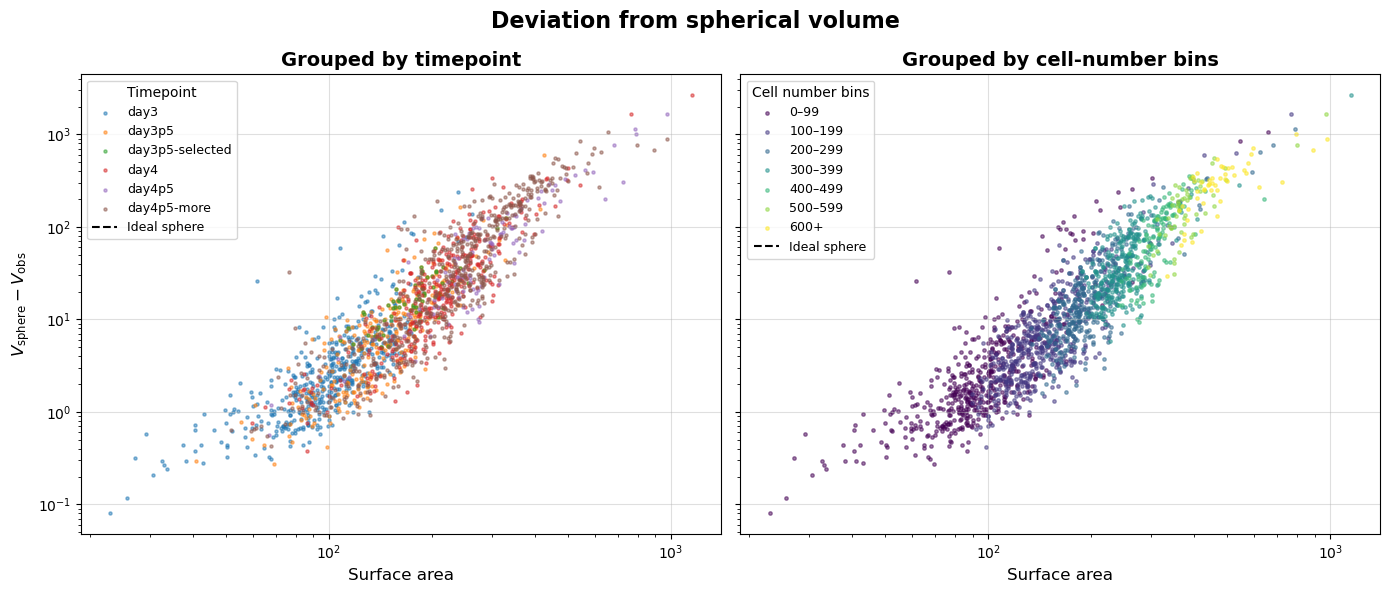

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import get_cmap

# --- Prepare color maps ---
cmap_time = get_cmap('tab10')  # for timepoints
colors_time = {tp: cmap_time(i % 10) for i, tp in enumerate(timepoints)}

cmap_bins = get_cmap('viridis')  # for cell-number bins
colors_bins = {label: cmap_bins(i / max(1, len(bin_labels)-1)) for i, label in enumerate(bin_labels)}

# --- Create figure with 2 subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# =====================================================
# 1️⃣ Left subplot — grouped by timepoint
# =====================================================
ax = axes[0]
for tp in timepoints:
    res = results[tp]
    areas = res['total_area']
    volumes = res['total_volume']

    # Ideal sphere volume
    V_sphere = (1.0 / (6.0 * np.sqrt(np.pi))) * (areas**1.5)
    deviation = V_sphere - volumes

    ax.scatter(
        areas,
        deviation,
        color=colors_time[tp],
        alpha=0.5,
        label=tp,
        s=5,
    )

ax.axhline(0, color='k', linestyle='--', lw=1.5, label="Ideal sphere")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Surface area", fontsize=12)
ax.set_ylabel(r"$V_{\mathrm{sphere}} - V_{\mathrm{obs}} $", fontsize=12)
ax.set_title("Grouped by timepoint", fontsize=14, fontweight='bold')
ax.legend(title="Timepoint", fontsize=9)
ax.grid(True, alpha=0.4)

# =====================================================
# 2️⃣ Right subplot — grouped by cell-number bins
# =====================================================
ax = axes[1]
for label in bin_labels:
    entries = binned_organoids_by_cellnum[label]
    if len(entries) == 0:
        continue

    areas_bin = []
    deviation_bin = []
    for tp, org_idx in entries:
        areas_org = results[tp]['total_area'][org_idx]
        volumes_org = results[tp]['total_volume'][org_idx]
        V_sphere_org = (1.0 / (6.0 * np.sqrt(np.pi))) * (areas_org**1.5)
        areas_bin.append(areas_org)
        deviation_bin.append(V_sphere_org - volumes_org)

    ax.scatter(
        areas_bin,
        deviation_bin,
        color=colors_bins[label],
        alpha=0.5,
        s=6,
        label=label
    )

ax.axhline(0, color='k', linestyle='--', lw=1.5, label="Ideal sphere")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Surface area", fontsize=12)
ax.set_title("Grouped by cell-number bins", fontsize=14, fontweight='bold')
ax.legend(title="Cell number bins", fontsize=9)
ax.grid(True, alpha=0.4)

# =====================================================
# Final formatting
# =====================================================
fig.suptitle("Deviation from spherical volume", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


Skipping tp=day4p5-more, org_idx=533 (out of bounds for 533)


/tmp/ipykernel_11140/337902686.py:6: RuntimeWarning: Mean of empty slice
  mean_C = np.nanmean(res["Corr_conn_all"], axis=0)   # (B,F,F)
/tmp/ipykernel_11140/337902686.py:35: RuntimeWarning: Mean of empty slice
  mean_corr = np.nanmean(corr_values, axis=0)


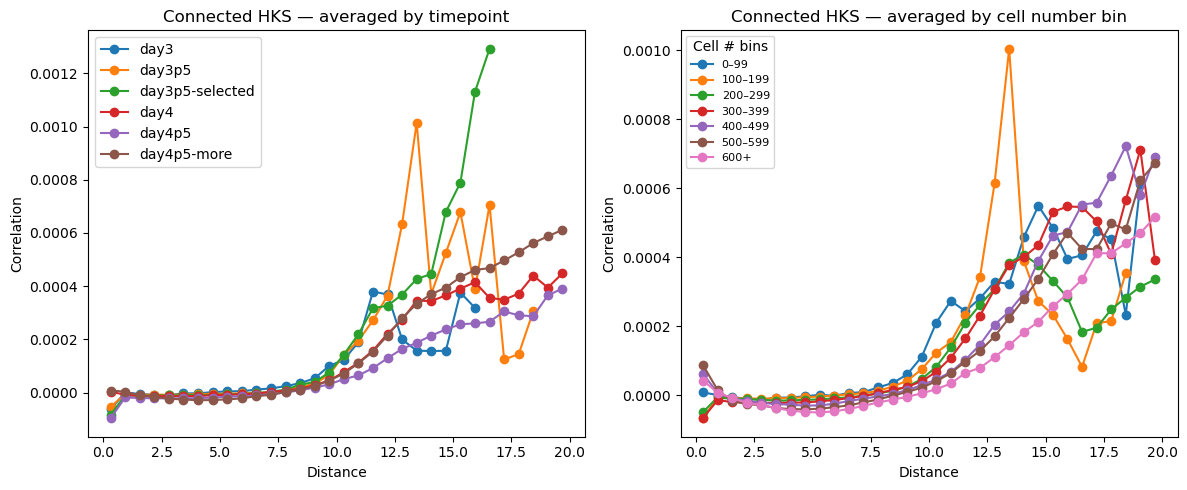

In [9]:
plt.figure(figsize=(12, 5))

# --- Left: Connected correlation averaged over timepoints ---
plt.subplot(1, 2, 1)
for tp, res in results.items():
    mean_C = np.nanmean(res["Corr_conn_all"], axis=0)   # (B,F,F)
    plt.plot(bin_centers, mean_C[:, 0, 0], 'o-', label=tp)

plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Connected HKS — averaged by timepoint")
plt.legend()

# --- Right: Connected correlation averaged over cell number bins ---
plt.subplot(1, 2, 2)
for bin_label in bin_labels:
    org_refs = binned_organoids_by_cellnum[bin_label]
    if len(org_refs) == 0:
        continue

    corr_values = []
    for tp, org_idx in org_refs:
        Corr_conn = results[tp]['Corr_conn_all']  # (n_org, B, F, F)

        # Defensive check to avoid out-of-bounds
        if org_idx < Corr_conn.shape[0]:
            corr_values.append(Corr_conn[org_idx, :, 0, 0])
        else:
            print(f"Skipping tp={tp}, org_idx={org_idx} (out of bounds for {Corr_conn.shape[0]})")

    if len(corr_values) == 0:
        continue

    corr_values = np.vstack(corr_values)
    mean_corr = np.nanmean(corr_values, axis=0)

    plt.plot(bin_centers, mean_corr, 'o-', label=bin_label)

plt.xlabel("Distance")
plt.ylabel("Correlation")
plt.title("Connected HKS — averaged by cell number bin")
plt.legend(title="Cell # bins", fontsize=8)
plt.tight_layout()



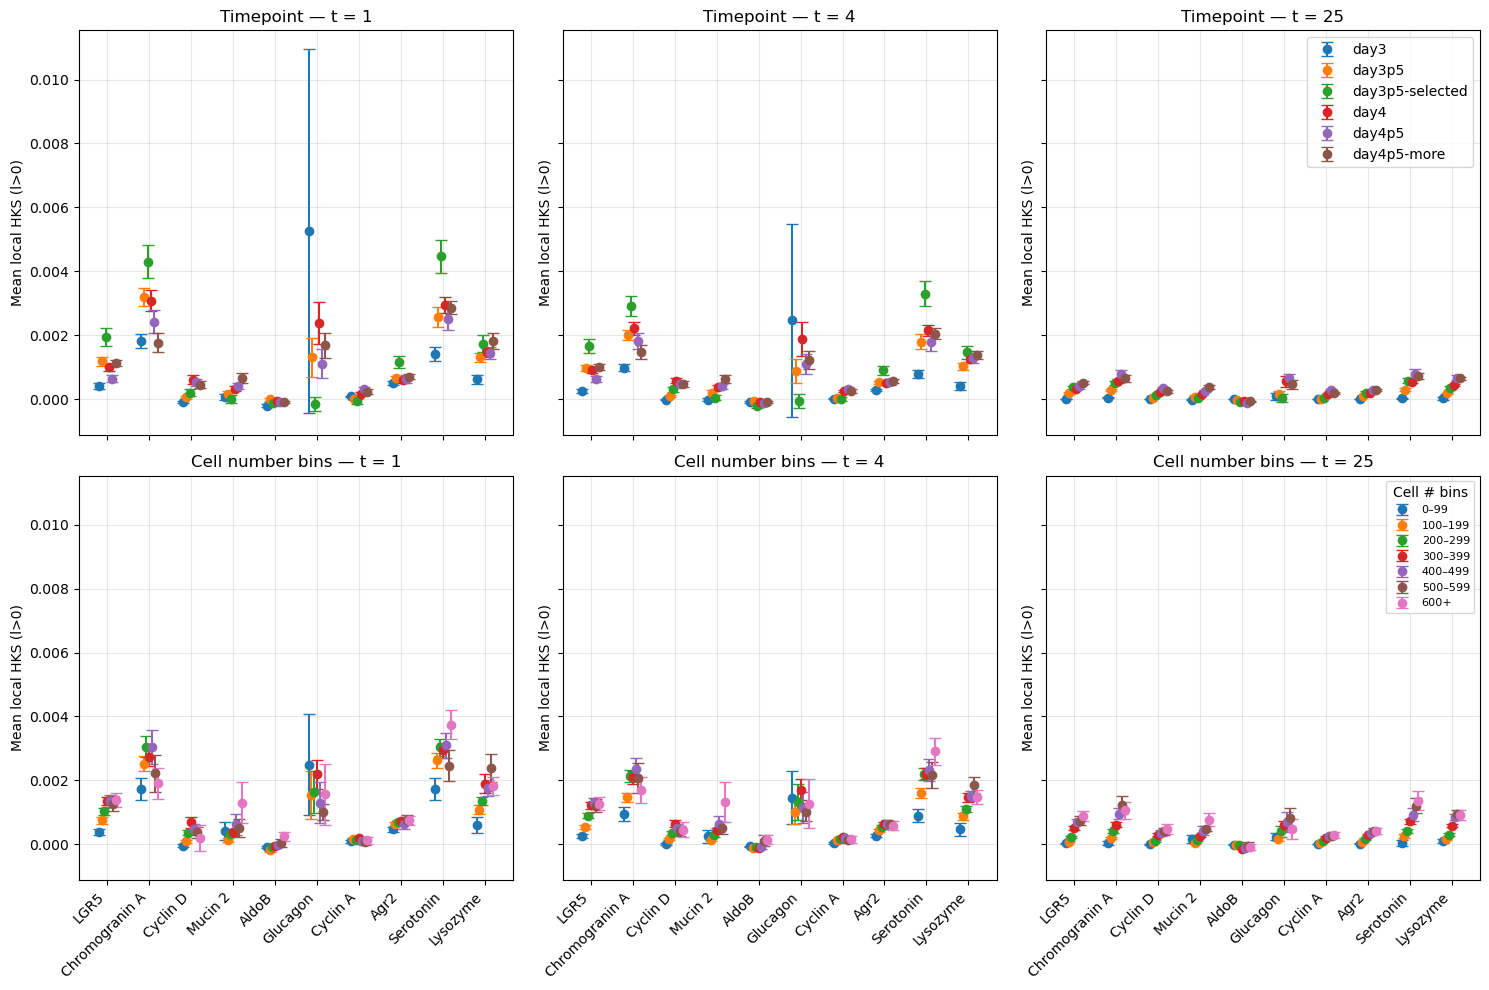

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Helper ---
def to_3d_markers(arr):
    """
    Ensures shape (n_org, n_markers, n_fields)
    """
    a = np.asarray(arr)
    if a.ndim == 2:  # (n_org, n_markers)
        a = a[:, :, None]
    elif a.ndim == 1:
        a = a[None, :, None]
    elif a.ndim != 3:
        raise ValueError(f"Expected 2D or 3D; got shape {a.shape}")
    return a

def mean_sem(arr2d):
    A = np.asarray(arr2d)
    means  = np.nanmean(A, axis=0)
    counts = np.sum(~np.isnan(A), axis=0)
    stds   = np.nanstd(A, axis=0, ddof=1)
    sems   = np.where(counts > 1, stds / np.sqrt(counts), np.nan)
    return means, sems

# --- Figure layout ---
field_labels = ["t = 1", "t = 4", "t = 25"]  # corresponds to columns in HKS arrays
n_fields = len(field_labels)

x = np.arange(len(marker_names))
offset_width = 0.2

fig, axes = plt.subplots(2, n_fields, figsize=(5 * n_fields, 10), sharex=True, sharey=True)

if n_fields == 1:
    axes = axes[:, None]  # keep 2D structure

# ---------------- 1) By timepoint ----------------
for f_idx, field_label in enumerate(field_labels):
    ax = axes[0, f_idx]

    n_tp = len(timepoints)
    time_offsets = np.linspace(-offset_width, offset_width, n_tp)

    for t_idx, tp in enumerate(timepoints):
        res = results[tp]
        hks_means = to_3d_markers(res['hks_cell_mean_all'])
        if hks_means.size == 0:
            continue

        # Select field
        data_field = hks_means[:, :, f_idx]
        mean_tp, sem_tp = mean_sem(data_field)

        if mean_tp.shape[0] != len(x):
            print(f"⚠ Skipping {tp}: mean has shape {mean_tp.shape}, expected {len(x)}")
            continue

        x_positions = x + time_offsets[t_idx]
        ax.errorbar(
            x_positions, mean_tp, yerr=sem_tp,
            fmt='o', capsize=4, label=tp
        )

    ax.set_title(f"Timepoint — {field_label}")
    ax.set_ylabel("Mean local HKS (l>0)")
    ax.grid(alpha=0.3)
    if f_idx == n_fields - 1:
        ax.legend()

# ---------------- 2) By cell-number bins ----------------
for f_idx, field_label in enumerate(field_labels):
    ax = axes[1, f_idx]

    n_bins = len(bin_labels)
    bin_offsets = np.linspace(-offset_width, offset_width, n_bins)

    for b_idx, bin_label in enumerate(bin_labels):
        org_refs = binned_organoids_by_cellnum[bin_label]
        if len(org_refs) == 0:
            continue

        bin_rows = []
        for tp, org_idx in org_refs:
            hks_all_tp = to_3d_markers(results[tp]['hks_cell_mean_all'])
            if 0 <= org_idx < hks_all_tp.shape[0]:
                bin_rows.append(hks_all_tp[org_idx, :, f_idx])

        if len(bin_rows) == 0:
            continue

        bin_data = np.vstack(bin_rows)
        mean_bin, sem_bin = mean_sem(bin_data)

        if mean_bin.shape[0] != len(x):
            print(f"⚠ Skipping bin {bin_label}: mean has shape {mean_bin.shape}, expected {len(x)}")
            continue

        x_positions = x + bin_offsets[b_idx]
        ax.errorbar(
            x_positions, mean_bin, yerr=sem_bin,
            fmt='o', capsize=4, label=bin_label
        )

    ax.set_title(f"Cell number bins — {field_label}")
    ax.set_xticks(x)
    ax.set_xticklabels(marker_names, rotation=45, ha='right')
    ax.set_ylabel("Mean local HKS (l>0)")
    ax.grid(alpha=0.3)
    if f_idx == n_fields - 1:
        ax.legend(title="Cell # bins", fontsize=8)

plt.tight_layout()
plt.show()


/tmp/ipykernel_11140/1623726831.py:10: RuntimeWarning: Mean of empty slice
  mean_profiles = np.nanmean(arr, axis=0)
/home/fmoller/miniforge3/envs/SphericalHarmonics/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


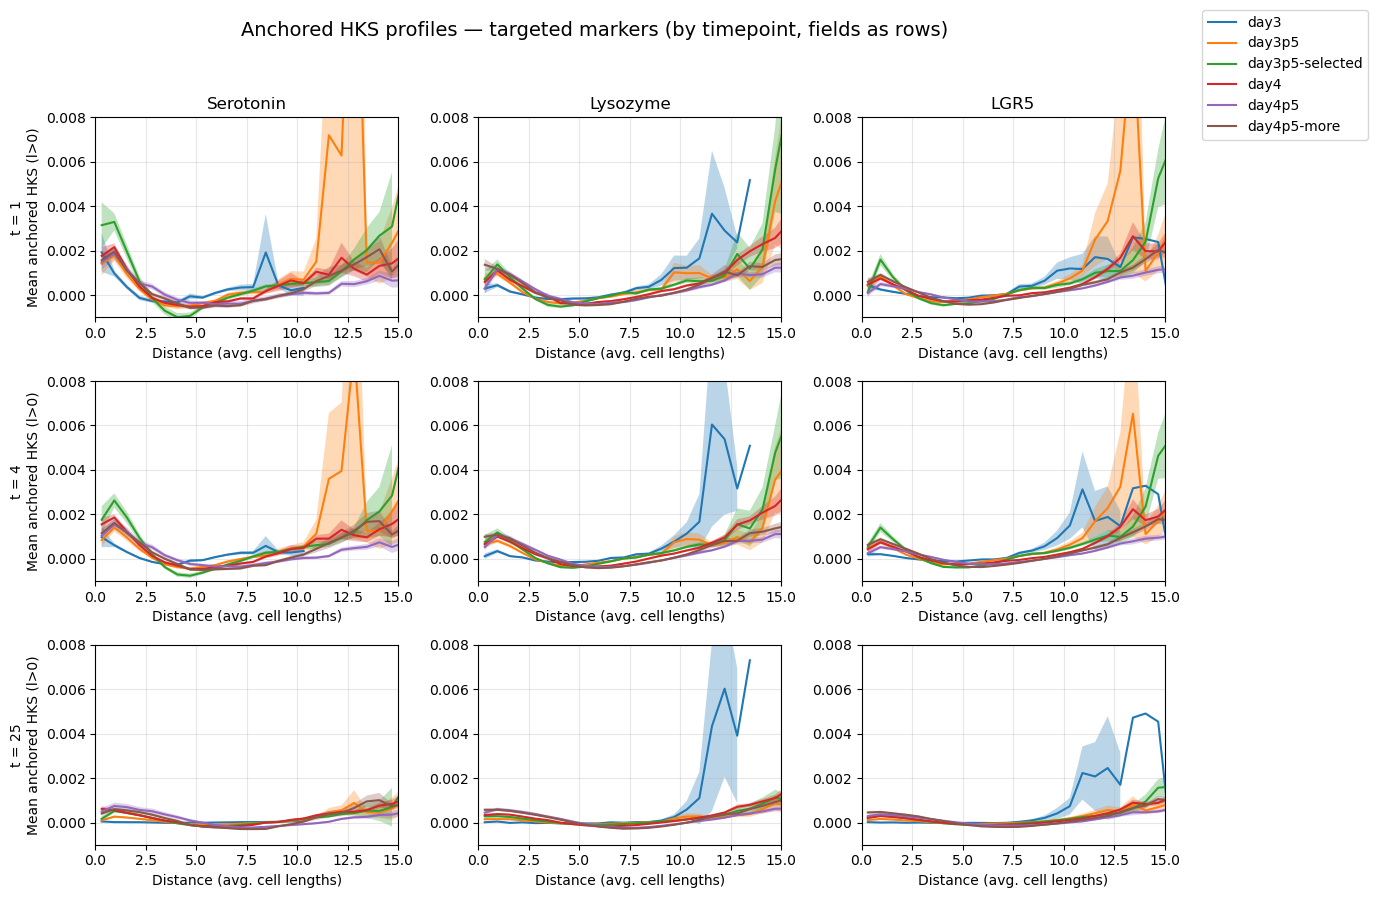

/tmp/ipykernel_11140/1623726831.py:131: RuntimeWarning: Mean of empty slice
  mean_bin = np.nanmean(bin_profiles, axis=0)


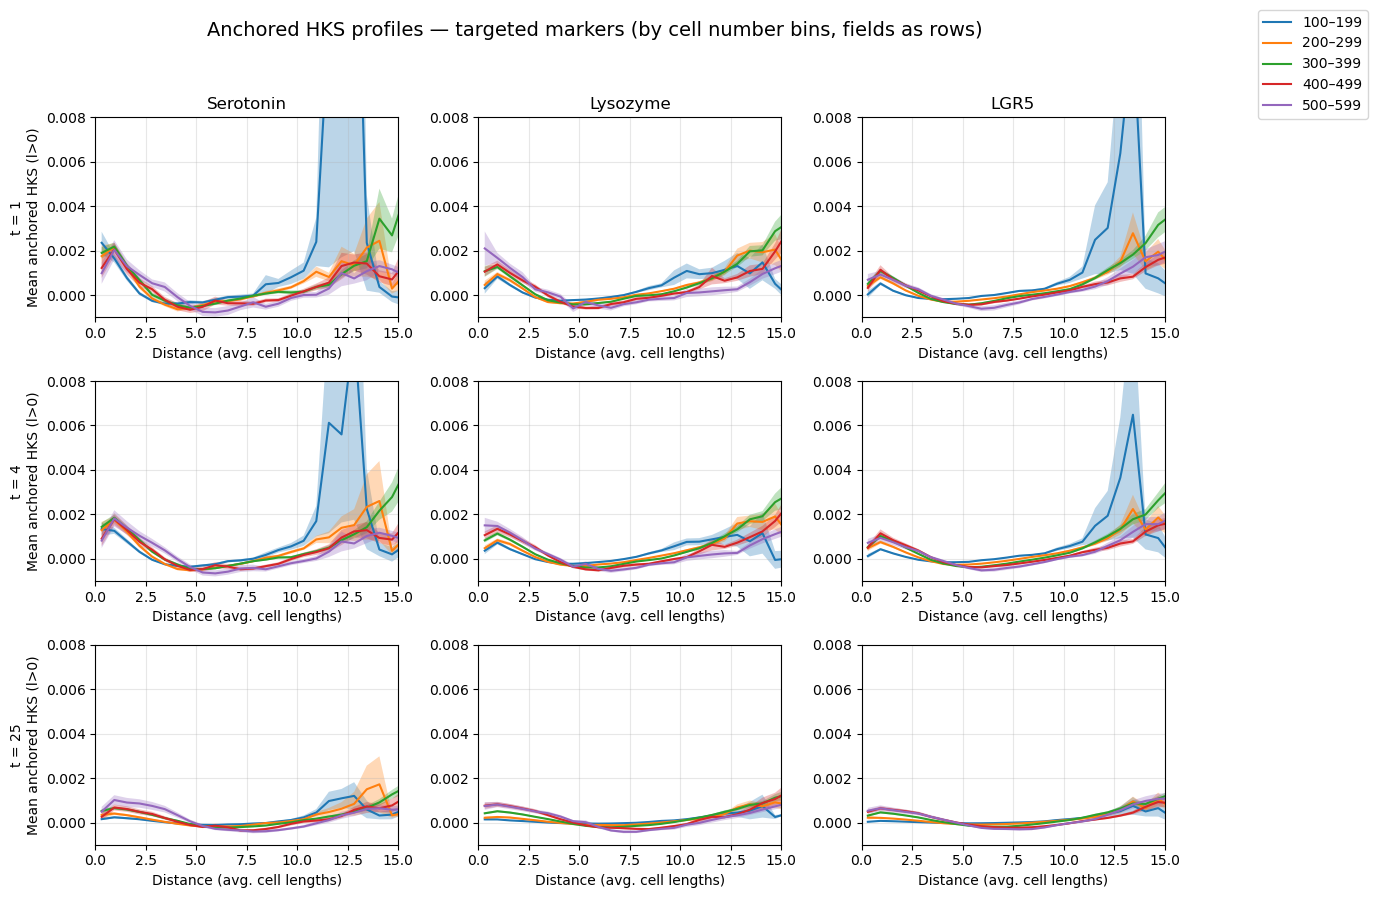

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Helper ---
def mean_sem_profiles(arr):
    """
    Compute mean and SEM across axis=0 for (n_org, n_markers, nbins, n_fields).
    Returns (mean, sem) with shape (n_markers, nbins, n_fields).
    """
    mean_profiles = np.nanmean(arr, axis=0)
    counts = np.sum(~np.isnan(arr), axis=0)
    std_profiles = np.nanstd(arr, axis=0, ddof=1)
    sem_profiles = np.where(counts > 1, std_profiles / np.sqrt(counts), np.nan)
    return mean_profiles, sem_profiles

# --- Field labels ---
field_labels = ["t = 1", "t = 4", "t = 25"]
n_fields = len(field_labels)

# --- Determine marker indices to plot ---
target_indices = [
    marker_names.index(m) for m in target_source_markers if m in marker_names
]
n_targets = len(target_indices)
if n_targets == 0:
    raise ValueError("No target_source_markers found in marker_names!")

# Determine number of bins and fields
sample_tp = next(iter(results))
nbins = results[sample_tp]['hks_profile_all'].shape[2]
n_fields_detected = results[sample_tp]['hks_profile_all'].shape[3] if results[sample_tp]['hks_profile_all'].ndim == 4 else 1
assert n_fields_detected == n_fields, f"Expected {n_fields} fields, found {n_fields_detected}"

# ============================================================
# 1. Plot by TIMEPOINT (targeted markers × fields as rows)
# ============================================================
fig, axes = plt.subplots(
    n_fields, n_targets,
    figsize=(4 * n_targets, 3 * n_fields),
    sharex=False, sharey=False
)

if n_fields == 1:
    axes = axes[None, :]
if n_targets == 1:
    axes = axes[:, None]

legend_handles = []
legend_labels = []

for f_idx, field_label in enumerate(field_labels):
    for ax_idx, m_idx in enumerate(target_indices):
        ax = axes[f_idx, ax_idx]

        for tp in timepoints:
            profiles_tp = results[tp]['hks_profile_all']
            if profiles_tp.size == 0:
                continue

            # profiles_tp shape: (n_org, n_markers, nbins, n_fields)
            mean_tp, sem_tp = mean_sem_profiles(profiles_tp)
            mean_tp_m = mean_tp[m_idx, :, f_idx]
            sem_tp_m = sem_tp[m_idx, :, f_idx]

            line, = ax.plot(bin_centers, mean_tp_m, '-', label=tp)
            ax.fill_between(
                bin_centers,
                mean_tp_m - sem_tp_m,
                mean_tp_m + sem_tp_m,
                alpha=0.3
            )

            if tp not in legend_labels:
                legend_handles.append(line)
                legend_labels.append(tp)

        if f_idx == 0:
            ax.set_title(marker_names[m_idx])
        if ax_idx == 0:
            ax.set_ylabel(f"{field_label}\nMean anchored HKS (l>0)")
        ax.set_xlabel("Distance (avg. cell lengths)")
        ax.grid(True, alpha=0.3)
        ax.set_xlim((0, 15))
        ax.set_ylim((-1e-3, 8e-3))

fig.suptitle("Anchored HKS profiles — targeted markers (by timepoint, fields as rows)", fontsize=14)
fig.legend(legend_handles, legend_labels, loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# fig.savefig("anchored_HKS_profiles_by_timepoint_all_fields.pdf", bbox_inches='tight')


# ============================================================
# 2. Plot by CELL NUMBER BIN (skip first/last bin, fields as rows)
# ============================================================
fig, axes = plt.subplots(
    n_fields, n_targets,
    figsize=(4 * n_targets, 3 * n_fields),
    sharex=False, sharey=False
)

if n_fields == 1:
    axes = axes[None, :]
if n_targets == 1:
    axes = axes[:, None]

legend_handles = []
legend_labels = []
bin_labels_to_plot = bin_labels[1:-1]

for f_idx, field_label in enumerate(field_labels):
    for ax_idx, m_idx in enumerate(target_indices):
        ax = axes[f_idx, ax_idx]

        for bin_label in bin_labels_to_plot:
            org_refs = binned_organoids_by_cellnum[bin_label]
            if len(org_refs) == 0:
                continue

            bin_profiles = []
            for tp, org_idx in org_refs:
                profiles_tp = results[tp]['hks_profile_all']
                if org_idx < profiles_tp.shape[0]:
                    bin_profiles.append(profiles_tp[org_idx, m_idx, :, f_idx])

            if len(bin_profiles) == 0:
                continue

            bin_profiles = np.vstack(bin_profiles)
            mean_bin = np.nanmean(bin_profiles, axis=0)
            sem_bin = np.nanstd(bin_profiles, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(bin_profiles), axis=0))

            line, = ax.plot(bin_centers, mean_bin, '-', label=bin_label)
            ax.fill_between(
                bin_centers,
                mean_bin - sem_bin,
                mean_bin + sem_bin,
                alpha=0.3
            )

            if bin_label not in legend_labels:
                legend_handles.append(line)
                legend_labels.append(bin_label)

        if f_idx == 0:
            ax.set_title(marker_names[m_idx])
        if ax_idx == 0:
            ax.set_ylabel(f"{field_label}\nMean anchored HKS (l>0)")
        ax.set_xlabel("Distance (avg. cell lengths)")
        ax.grid(True, alpha=0.3)
        ax.set_xlim((0, 15))
        ax.set_ylim((-1e-3, 8e-3))

fig.suptitle("Anchored HKS profiles — targeted markers (by cell number bins, fields as rows)", fontsize=14)
fig.legend(legend_handles, legend_labels, loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# fig.savefig("anchored_HKS_profiles_by_cellbins_all_fields.pdf", bbox_inches='tight')


/tmp/ipykernel_11140/3505032067.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')


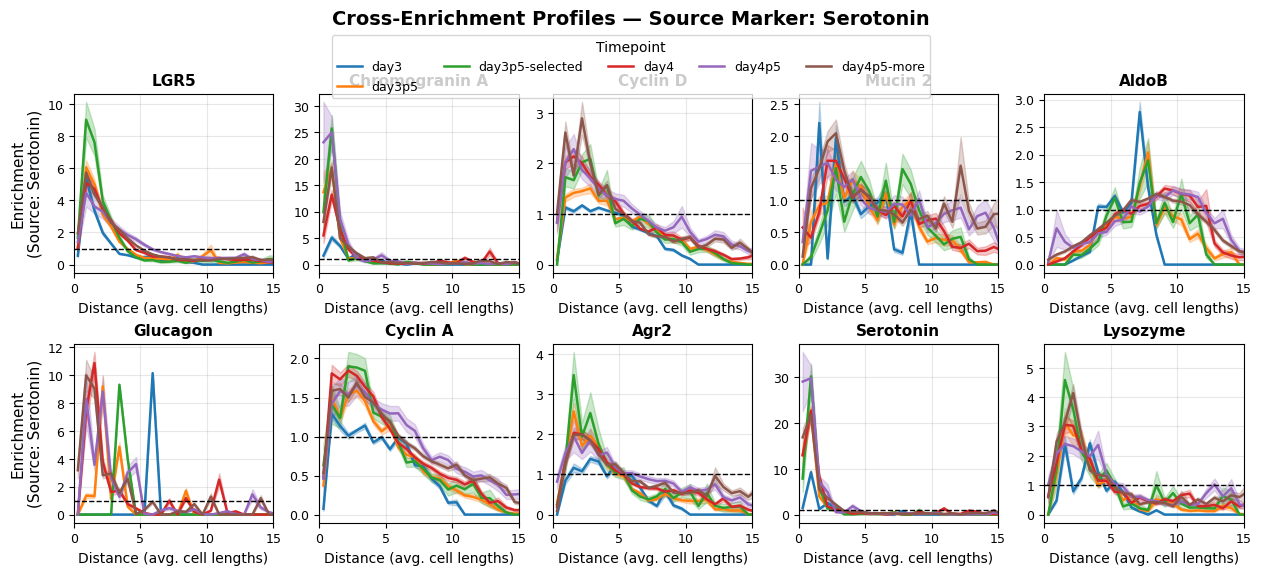

/tmp/ipykernel_11140/3505032067.py:45: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(enrichment_curves, axis=0)


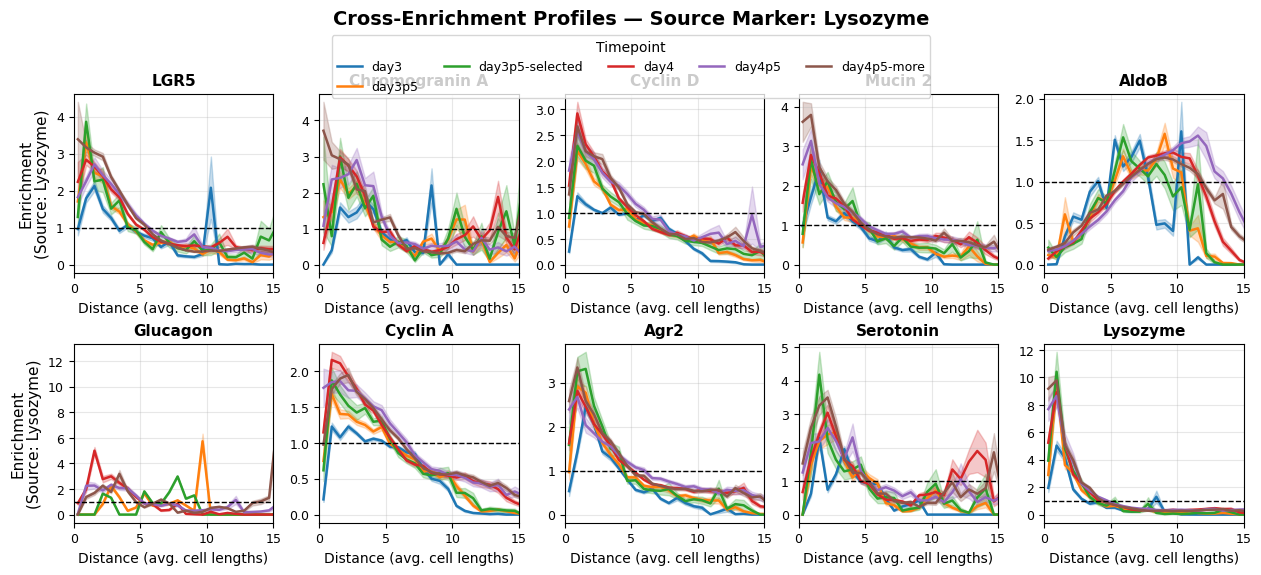

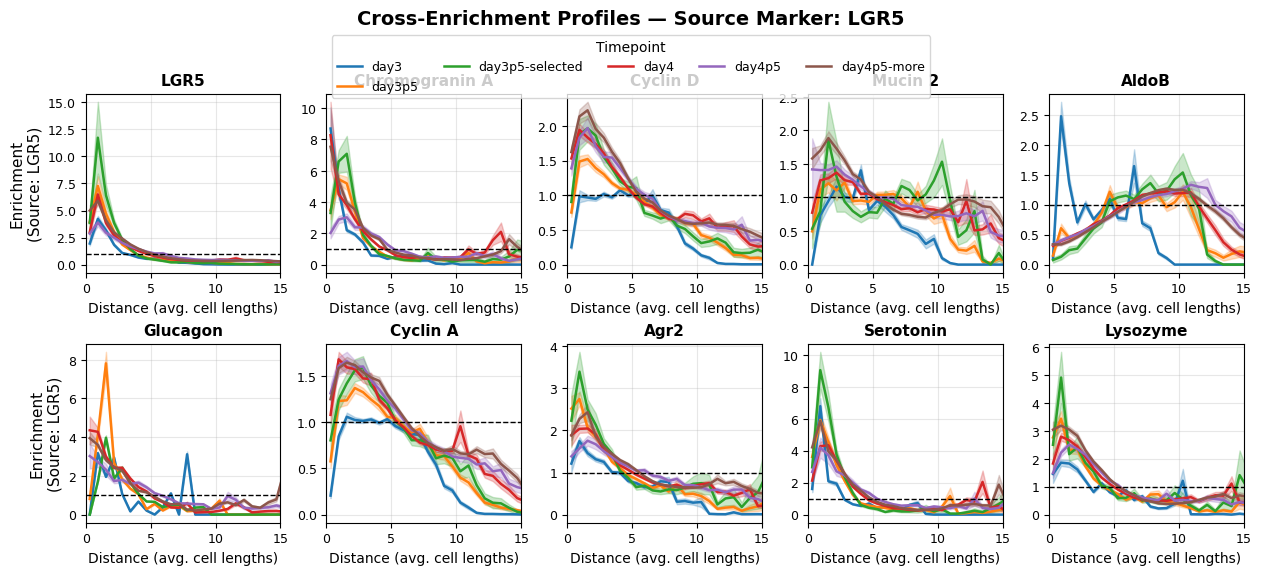

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# ------------------------------
# Setup
# ------------------------------
sample_tp = next(iter(results))
_, n_markers, nbins, _ = results[sample_tp]["Enrichment_all"].shape

# Example targeted markers list
# targeted_markers = ["SOX2", "PAX6", "TUBB3"]
# target_indices = [np.where(marker_names == m)[0][0] for m in targeted_markers]

# Color map for timepoints
cmap = get_cmap('tab10')
colors_tp = {tp: cmap(i % 10) for i, tp in enumerate(timepoints)}

# ------------------------------
# Plot per SOURCE marker
# ------------------------------
n_cols = int(np.ceil(n_markers / 2))
n_rows = 2

for i_source in target_indices:
    source_name = marker_names[i_source]

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.5 * n_cols, 2.5 * n_rows),
        sharex=False, sharey=False,
        constrained_layout=True
    )
    axes = axes.ravel()

    for j_target in range(n_markers):
        ax = axes[j_target]

        for tp_idx, (tp, res) in enumerate(results.items()):
            n_organoids = res["Enrichment_all"].shape[0]
            if n_organoids == 0:
                continue

            enrichment_curves = res["Enrichment_all"][:, i_source, :, j_target]
            mean_curve = np.nanmean(enrichment_curves, axis=0)
            std_curve  = np.nanstd(enrichment_curves, axis=0)
            sem_curve  = std_curve / np.sqrt(n_organoids)

            ax.plot(
                bin_centers,
                mean_curve,
                color=colors_tp[tp],
                lw=1.8,
                label=tp
            )
            ax.fill_between(
                bin_centers,
                mean_curve - sem_curve,
                mean_curve + sem_curve,
                color=colors_tp[tp],
                alpha=0.25
            )

        ax.axhline(1.0, color='k', linestyle='--', linewidth=1)
        ax.set_xlim(0, 15)
        ax.set_title(marker_names[j_target], fontsize=11, fontweight='bold')
        ax.tick_params(axis='both', labelsize=9)
        ax.grid(alpha=0.3)

        ax.set_xlabel("Distance (avg. cell lengths)", fontsize=10)
        if j_target % n_cols == 0:
            ax.set_ylabel(f"Enrichment\n(Source: {source_name})", fontsize=11)

    # Turn off any unused subplots if n_markers is not a perfect multiple of n_cols
    for j in range(n_markers, len(axes)):
        axes[j].axis('off')

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.08),
        ncol=min(len(timepoints), 5),
        fontsize=9,
        title="Timepoint",
        title_fontsize=10
    )

    fig.suptitle(
        f"Cross-Enrichment Profiles — Source Marker: {source_name}",
        fontsize=14, fontweight='bold', y=1.12
    )


    plt.show()

    # fig.savefig(f"enrichment_{source_name}.pdf", bbox_inches='tight')



/tmp/ipykernel_11140/3769491766.py:62: RuntimeWarning: Mean of empty slice
  boot_means[b] = np.nanmean(curves[idx, :], axis=0)


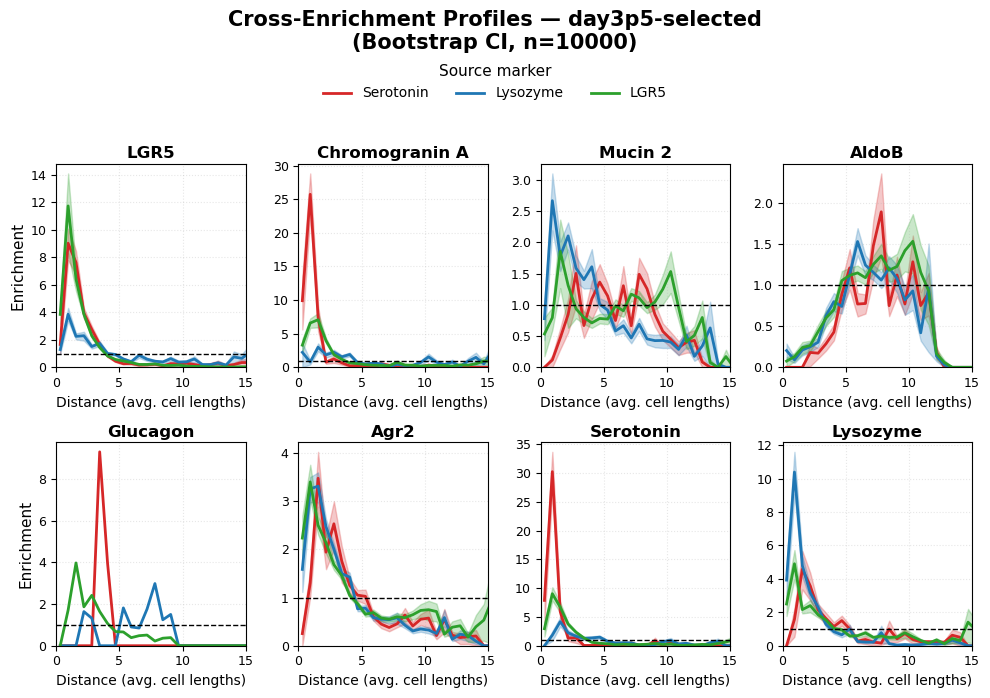

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# ------------------------------
# Settings
# ------------------------------
tp_to_plot = list(results.keys())[2]  # "day3p5-selected"
res = results[tp_to_plot]

_, n_markers, nbins, _ = res["Enrichment_all"].shape

# Sources: Serotonin + Lysozyme
source_markers = ["Serotonin", "Lysozyme", "LGR5"]
source_indices = [marker_names.index(m) for m in source_markers if m in marker_names]
source_colors = {"Serotonin": "tab:red", "Lysozyme": "tab:blue", "LGR5": "tab:green"}

# Exclude targets
excluded_targets = {"Cyclin A", "Cyclin D"}
target_indices = [i for i, name in enumerate(marker_names) if name not in excluded_targets]
n_targets = len(target_indices)

# Bootstrapping
n_boot = 10000
# lower_q, upper_q = 2.5, 97.5
# lower_q, upper_q = 10.0, 90.0
lower_q, upper_q = 25, 75


# Subplot grid
n_cols = int(np.ceil(n_targets / 2))
n_rows = 2

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(2.5 * n_cols, 3.5 * n_rows),
    sharex=False, sharey=False
)
axes = axes.ravel()

# ------------------------------
# Plot for each TARGET
# ------------------------------
for plot_idx, j_target in enumerate(target_indices):
    ax = axes[plot_idx]
    target_name = marker_names[j_target]

    for i_source in source_indices:
        source_name = marker_names[i_source]
        curves = res["Enrichment_all"][:, i_source, :, j_target]  # (n_org, nbins)
        n_org = curves.shape[0]
        if n_org == 0:
            continue

        # Mean curve
        mean_curve = np.nanmean(curves, axis=0)

        # Bootstrap over organoids
        boot_means = np.empty((n_boot, nbins))
        for b in range(n_boot):
            idx = np.random.randint(0, n_org, size=n_org)
            boot_means[b] = np.nanmean(curves[idx, :], axis=0)

        lower_ci = np.percentile(boot_means, lower_q, axis=0)
        upper_ci = np.percentile(boot_means, upper_q, axis=0)

        # Plot
        ax.plot(
            bin_centers,
            mean_curve,
            color=source_colors[source_name],
            lw=2.0,
            label=source_name
        )
        ax.fill_between(
            bin_centers,
            lower_ci,
            upper_ci,
            color=source_colors[source_name],
            alpha=0.25
        )

    ax.axhline(1.0, color='k', linestyle='--', linewidth=1)
    ax.set_xlim(0, 15)
    ax.set_ylim(bottom=0)
    ax.set_title(target_name, fontsize=12, fontweight='bold', pad=4)
    ax.tick_params(axis='both', labelsize=9)
    ax.grid(alpha=0.3, linestyle=':')

    ax.set_xlabel("Distance (avg. cell lengths)", fontsize=10)
    if plot_idx % n_cols == 0:
        ax.set_ylabel("Enrichment", fontsize=11)

# Turn off unused subplots
for j in range(n_targets, len(axes)):
    axes[j].axis('off')

# Adjust layout before adding legend & title
fig.subplots_adjust(top=0.85)

# Legend BELOW the title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.93),
    ncol=len(source_markers),
    fontsize=10,
    title="Source marker",
    title_fontsize=11,
    frameon=False
)

# Title
fig.suptitle(
    f"Cross-Enrichment Profiles — {tp_to_plot}\n(Bootstrap CI, n={n_boot})",
    fontsize=15, fontweight='bold', y=0.99
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

# fig.savefig(f"enrichment_{tp_to_plot}_Serotonin_Lysozyme_bootstrap.pdf", bbox_inches='tight')


In [24]:
# import pandas as pd

# # ------------------------------
# # Save data to CSV
# # ------------------------------
# rows = []

# for j_target in target_indices:
#     target_name = marker_names[j_target]

#     for i_source in source_indices:
#         source_name = marker_names[i_source]
#         curves = res["Enrichment_all"][:, i_source, :, j_target]  # (n_org, nbins)
#         n_org = curves.shape[0]
#         if n_org == 0:
#             continue

#         # Mean curve
#         mean_curve = np.nanmean(curves, axis=0)

#         # Bootstrap CI
#         boot_means = np.empty((n_boot, nbins))
#         for b in range(n_boot):
#             idx = np.random.randint(0, n_org, size=n_org)
#             boot_means[b] = np.nanmean(curves[idx, :], axis=0)
#         lower_ci = np.percentile(boot_means, lower_q, axis=0)
#         upper_ci = np.percentile(boot_means, upper_q, axis=0)

#         # Collect rows
#         for r_idx, r in enumerate(bin_centers):
#             rows.append({
#                 "timepoint": tp_to_plot,
#                 "source_marker": source_name,
#                 "target_marker": target_name,
#                 "distance_bin_center": r,
#                 "mean_enrichment": mean_curve[r_idx],
#                 f"lower_{lower_q}": lower_ci[r_idx],
#                 f"upper_{upper_q}": upper_ci[r_idx],
#                 "n_organoids": n_org
#             })

# # Create DataFrame and save
# df = pd.DataFrame(rows)
# csv_path = f"enrichment_data_{tp_to_plot}_bootstrap.csv"
# df.to_csv(csv_path, index=False)
# print(f"✅ Saved enrichment data to {csv_path}")

/tmp/ipykernel_11140/885138621.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_bins = get_cmap('viridis')


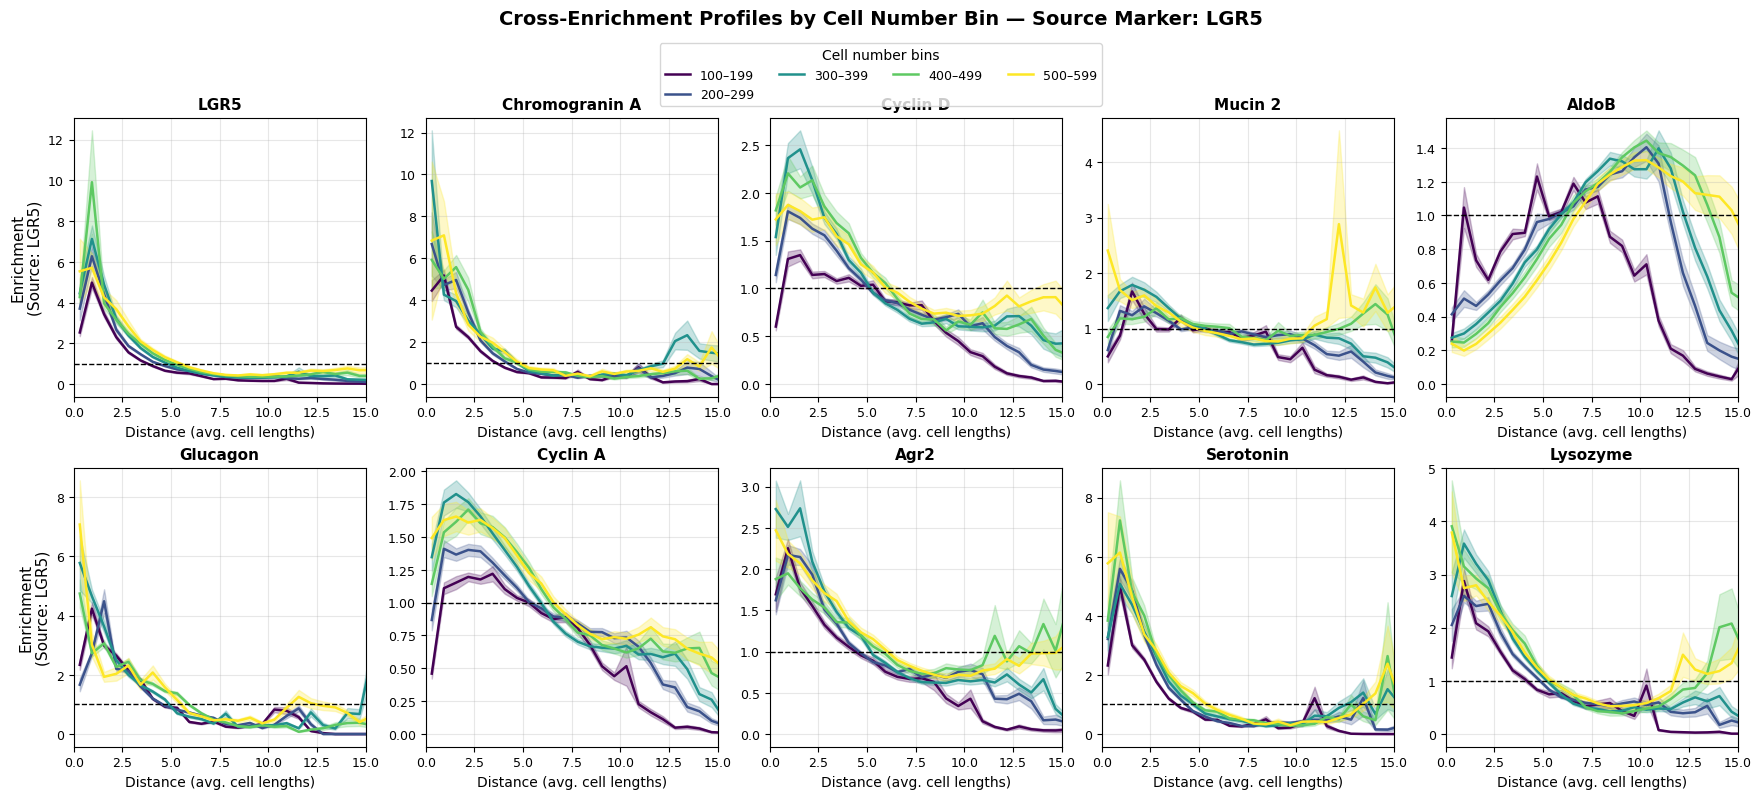

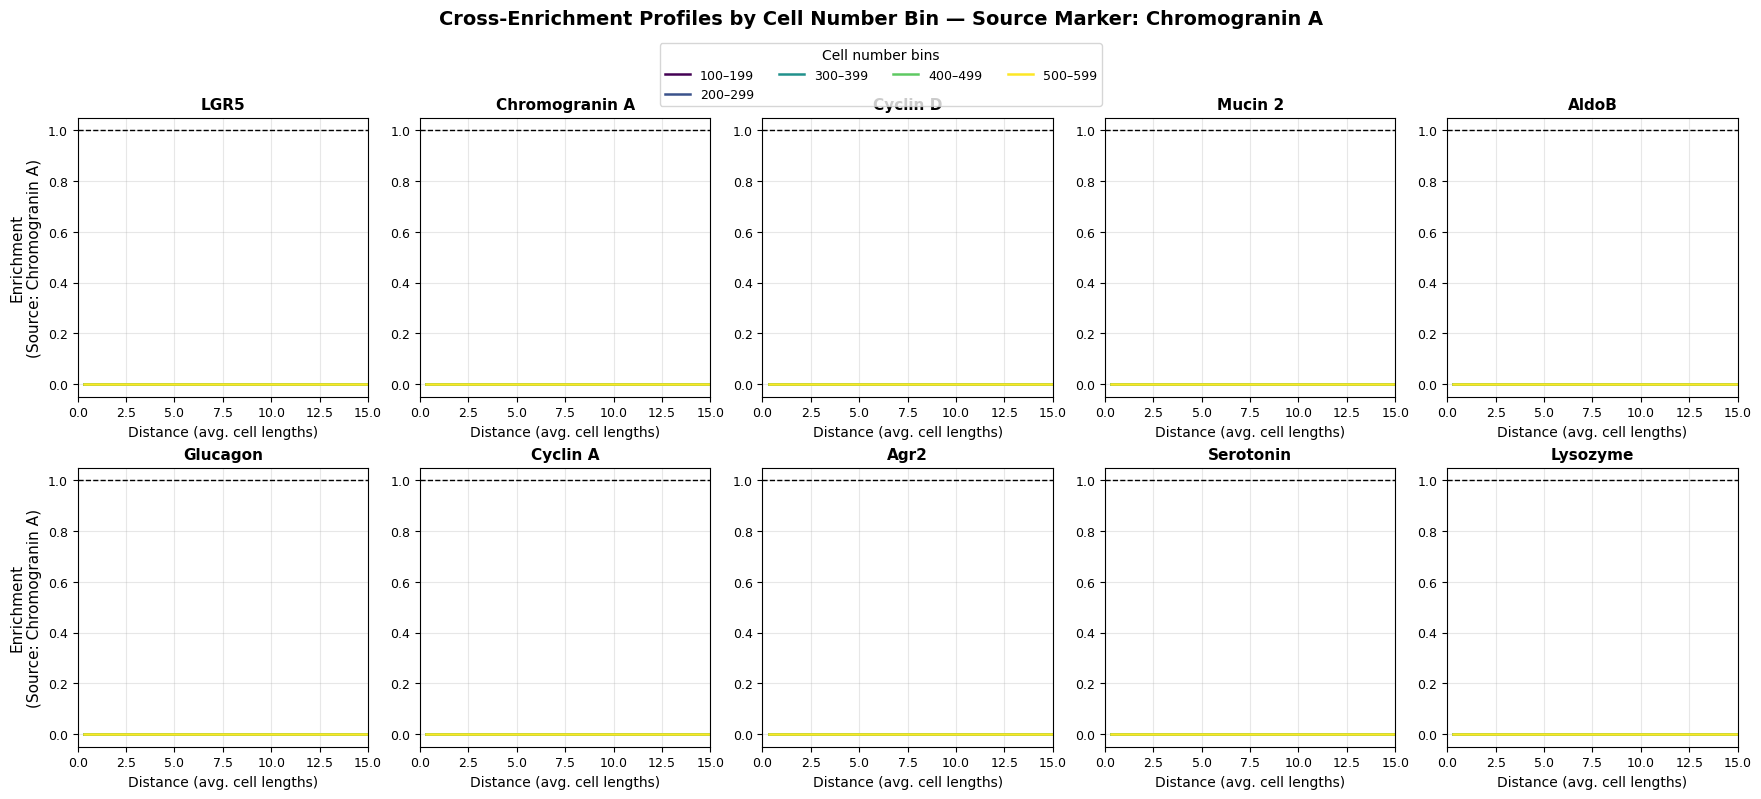

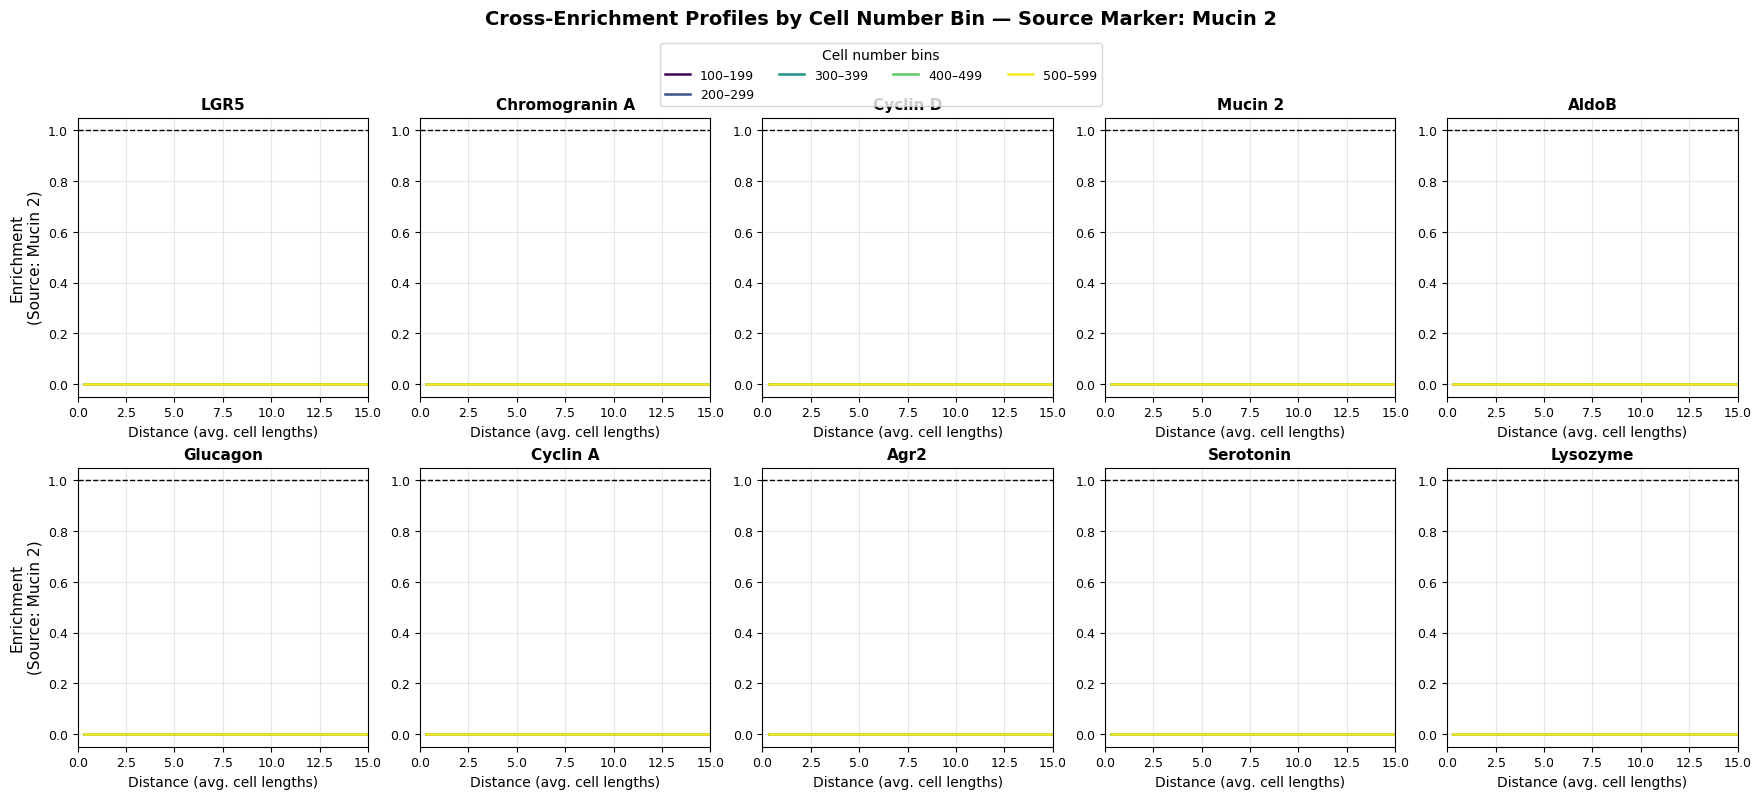

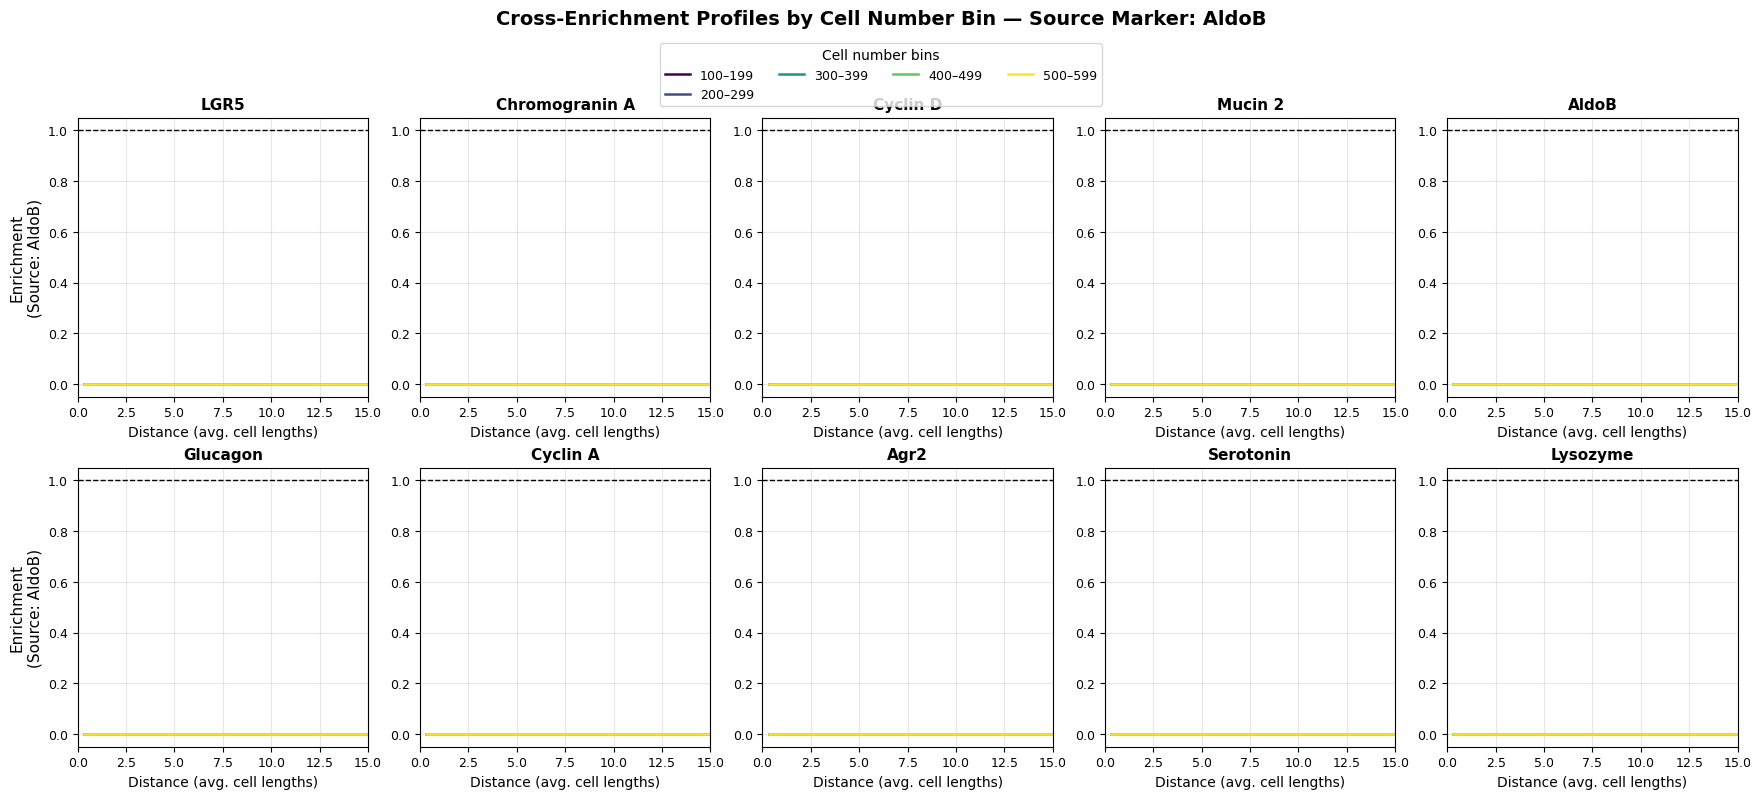

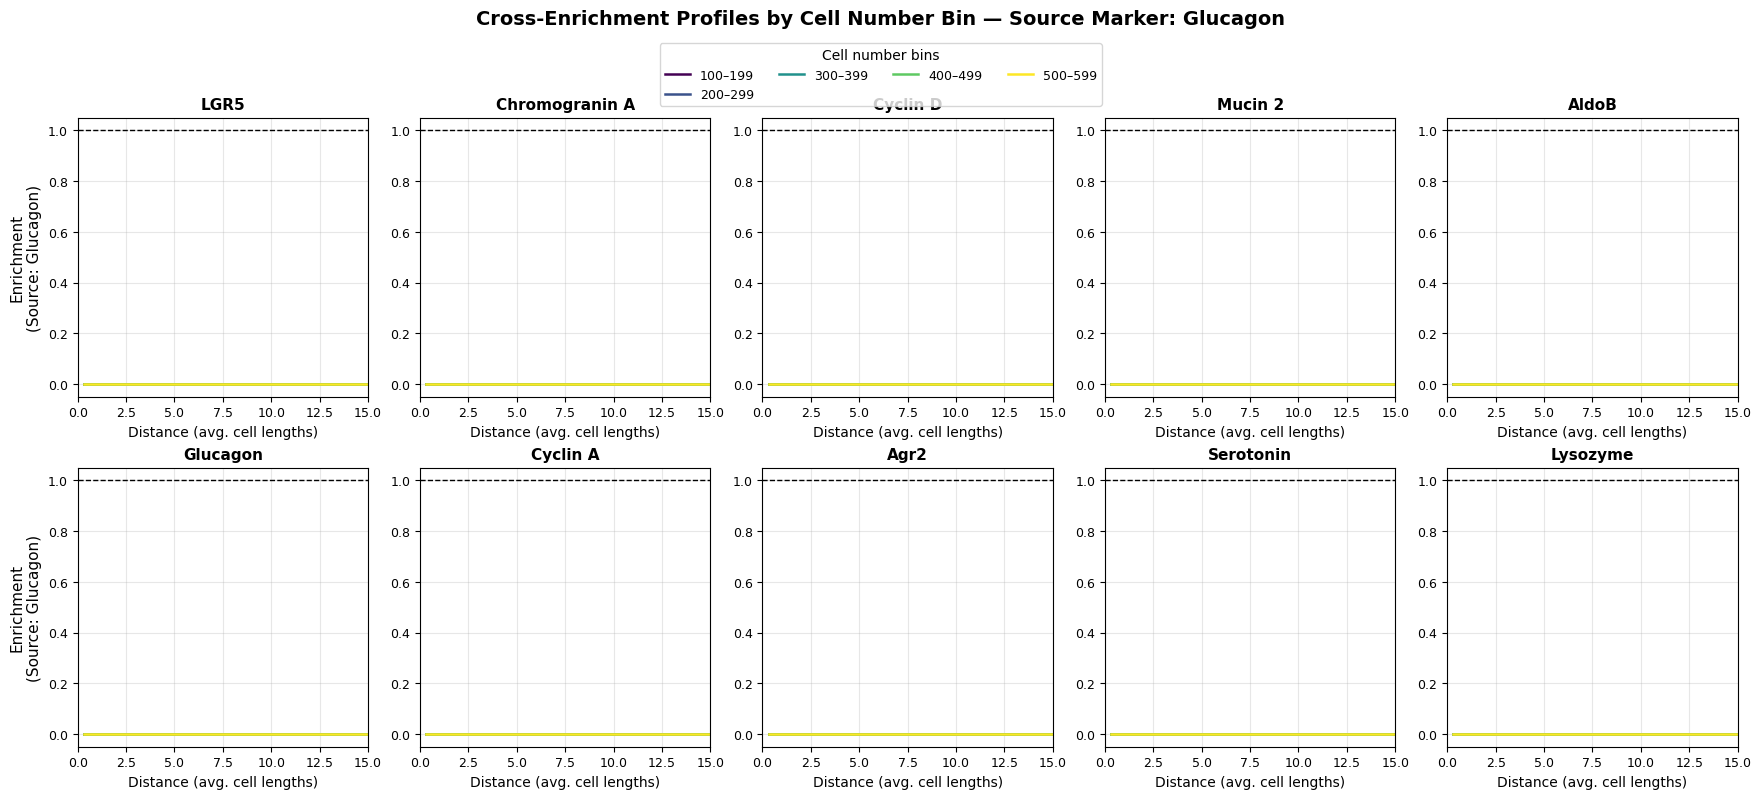

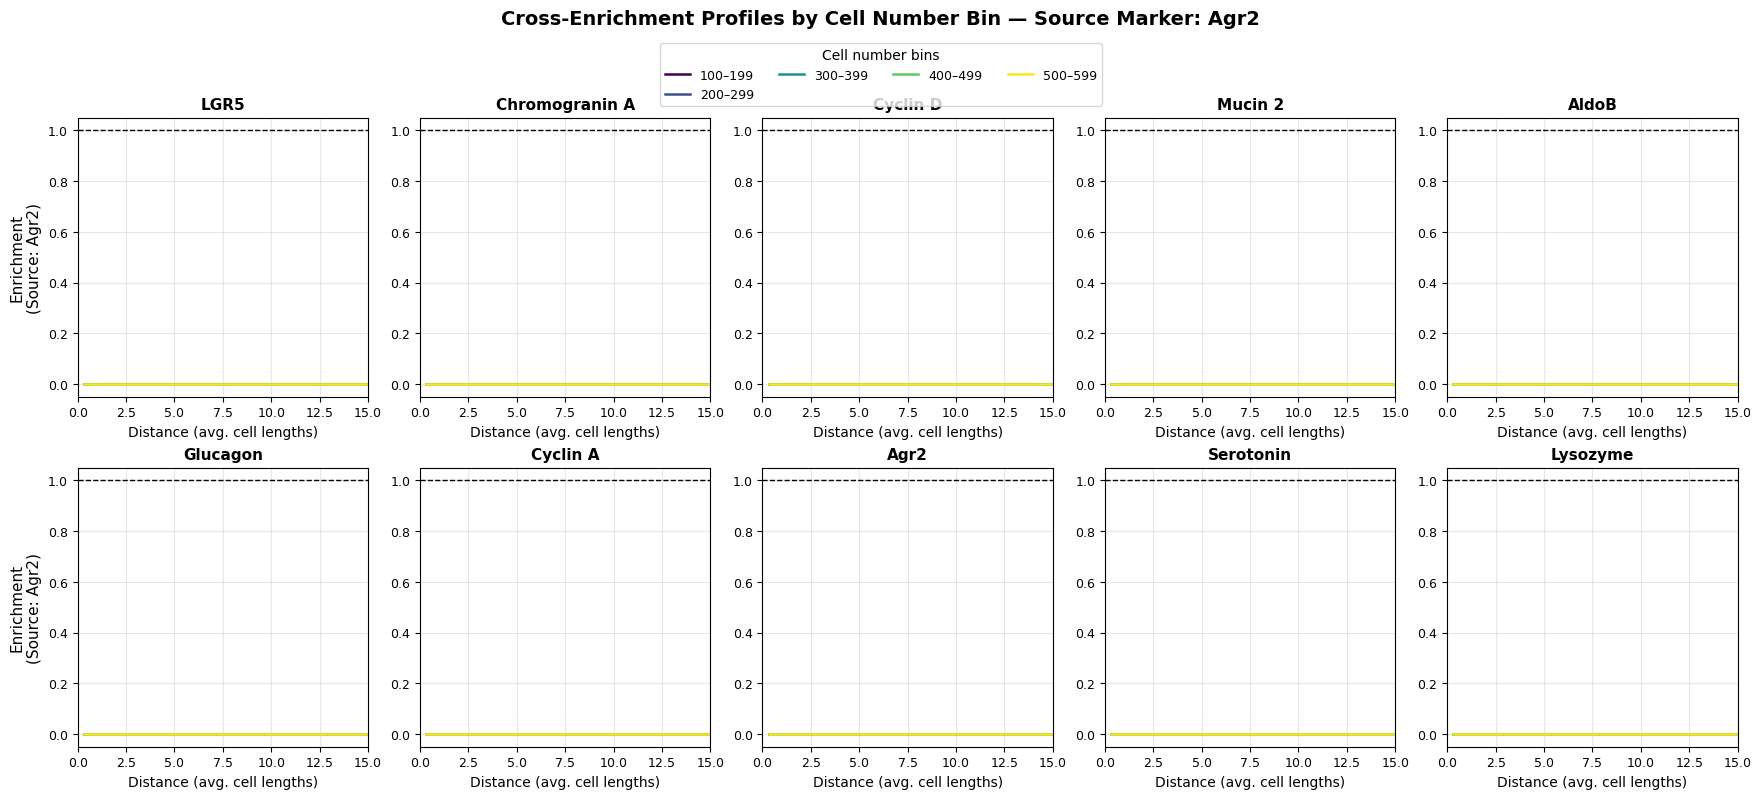

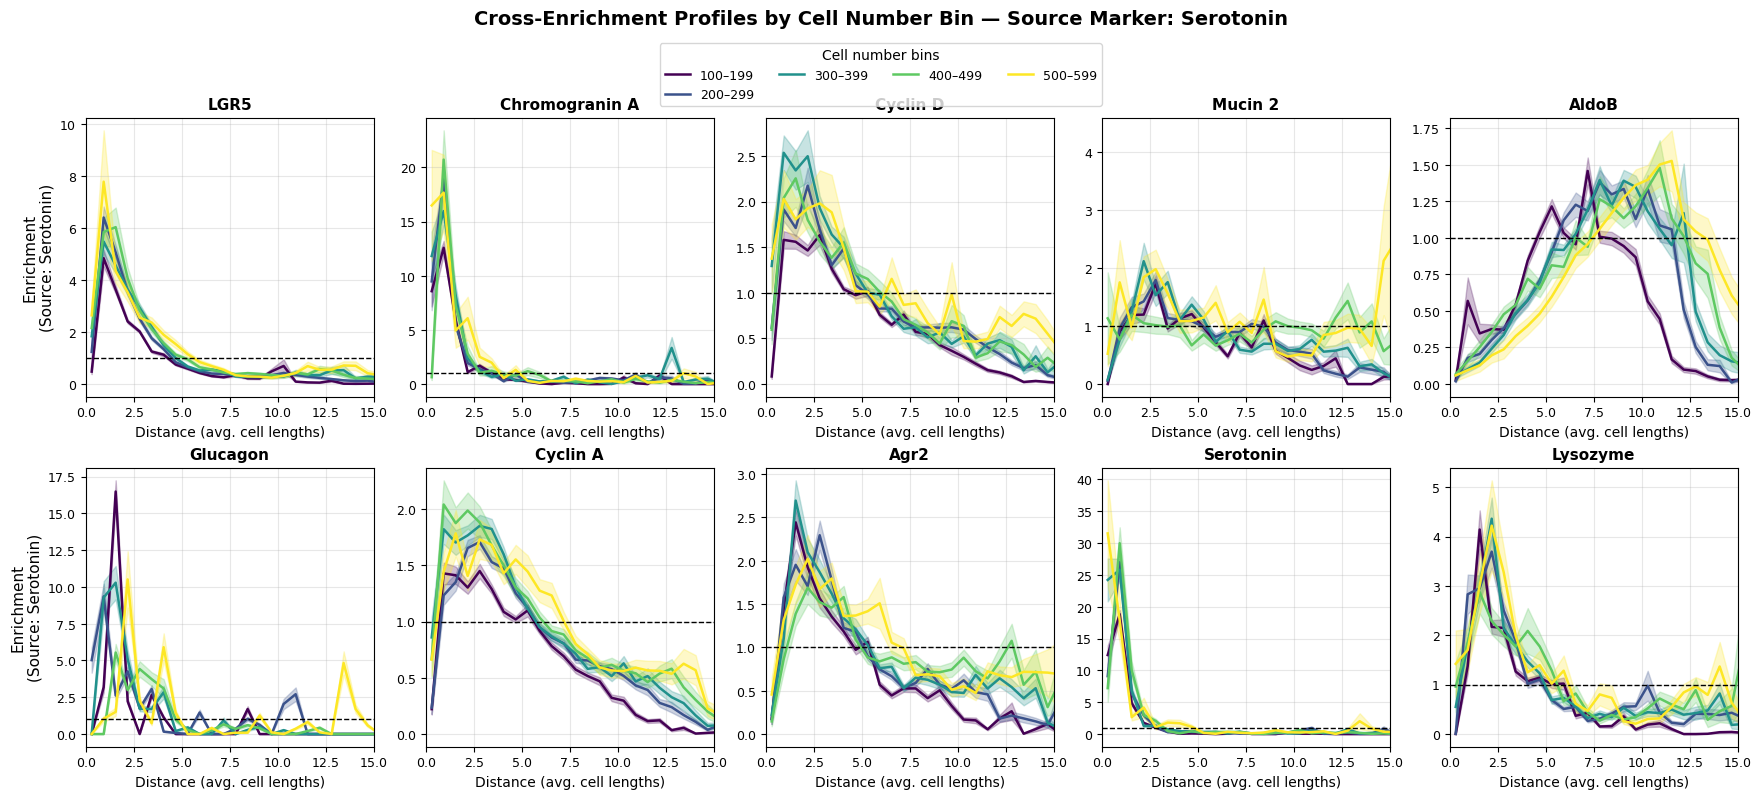

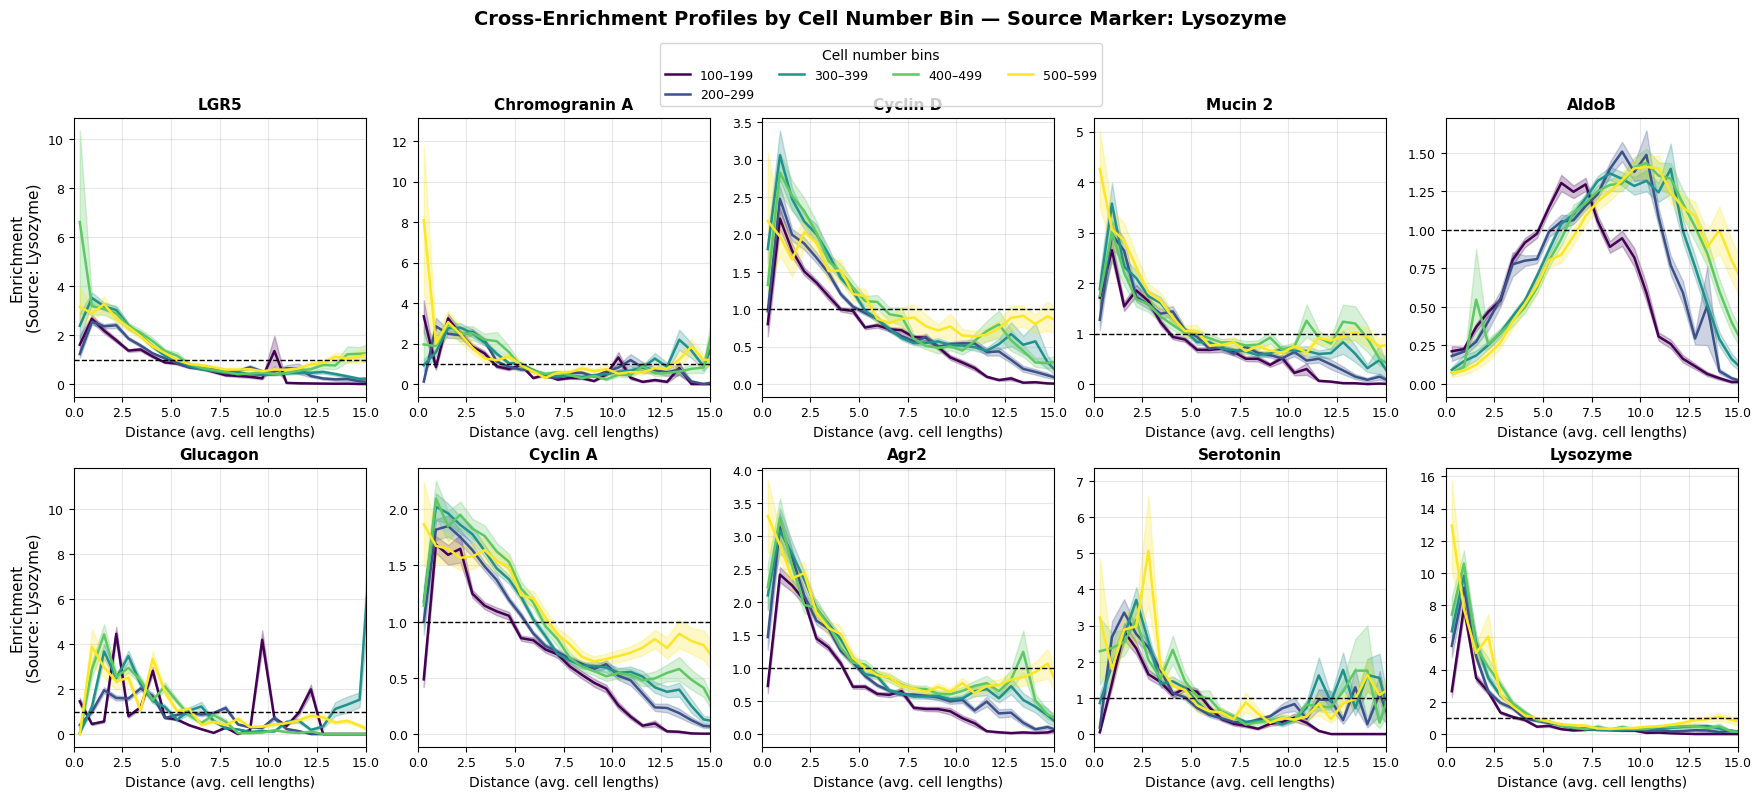

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# Color map for cell-number bins
cmap_bins = get_cmap('viridis')

# Exclude first and last bins
bin_labels_inner = bin_labels[1:-1]
colors_bins = {
    label: cmap_bins(i / max(1, len(bin_labels_inner) - 1))
    for i, label in enumerate(bin_labels_inner)
}

# Number of columns/rows for subplots
n_cols = int(np.ceil(n_markers / 2))
n_rows = 2

# ------------------------------
# Plot per SOURCE marker (targeted only)
# ------------------------------
for i_source in target_indices:
    source_name = marker_names[i_source]

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.5 * n_cols, 3.5 * n_rows),
        sharex=False, sharey=False,
        constrained_layout=True
    )
    axes = axes.ravel()

    for j_target in range(n_markers):
        ax = axes[j_target]

        # Plot ensemble-averaged enrichment for each (inner) cell number bin
        for bin_label in bin_labels_inner:
            org_refs = binned_organoids_by_cellnum[bin_label]
            if len(org_refs) == 0:
                continue

            curves = []
            for tp, org_idx in org_refs:
                Enrich = results[tp]["Enrichment_all"]  # (n_org, M, B, M)
                if org_idx < Enrich.shape[0]:
                    curves.append(Enrich[org_idx, i_source, :, j_target])

            if len(curves) == 0:
                continue

            curves = np.vstack(curves)
            mean_curve = np.nanmean(curves, axis=0)
            std_curve = np.nanstd(curves, axis=0)
            sem_curve = std_curve / np.sqrt(curves.shape[0])

            ax.plot(
                bin_centers,
                mean_curve,
                color=colors_bins[bin_label],
                lw=1.8,
                label=bin_label
            )
            ax.fill_between(
                bin_centers,
                mean_curve - sem_curve,
                mean_curve + sem_curve,
                color=colors_bins[bin_label],
                alpha=0.25
            )

        ax.axhline(1.0, color='k', linestyle='--', linewidth=1)
        ax.set_xlim(0, 15)
        ax.set_title(marker_names[j_target], fontsize=11, fontweight='bold')
        ax.tick_params(axis='both', labelsize=9)
        ax.grid(alpha=0.3)
        ax.set_xlabel("Distance (avg. cell lengths)", fontsize=10)
        if j_target % n_cols == 0:
            ax.set_ylabel(f"Enrichment\n(Source: {source_name})", fontsize=11)

    # Turn off unused subplots
    for j in range(n_markers, len(axes)):
        axes[j].axis('off')

    # Shared legend for inner bins
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.08),
        ncol=min(len(bin_labels_inner), 4),
        fontsize=9,
        title="Cell number bins",
        title_fontsize=10
    )

    fig.suptitle(
        f"Cross-Enrichment Profiles by Cell Number Bin — Source Marker: {source_name}",
        fontsize=14, fontweight='bold', y=1.12
    )

    plt.show()


/tmp/ipykernel_11140/3878059829.py:90: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


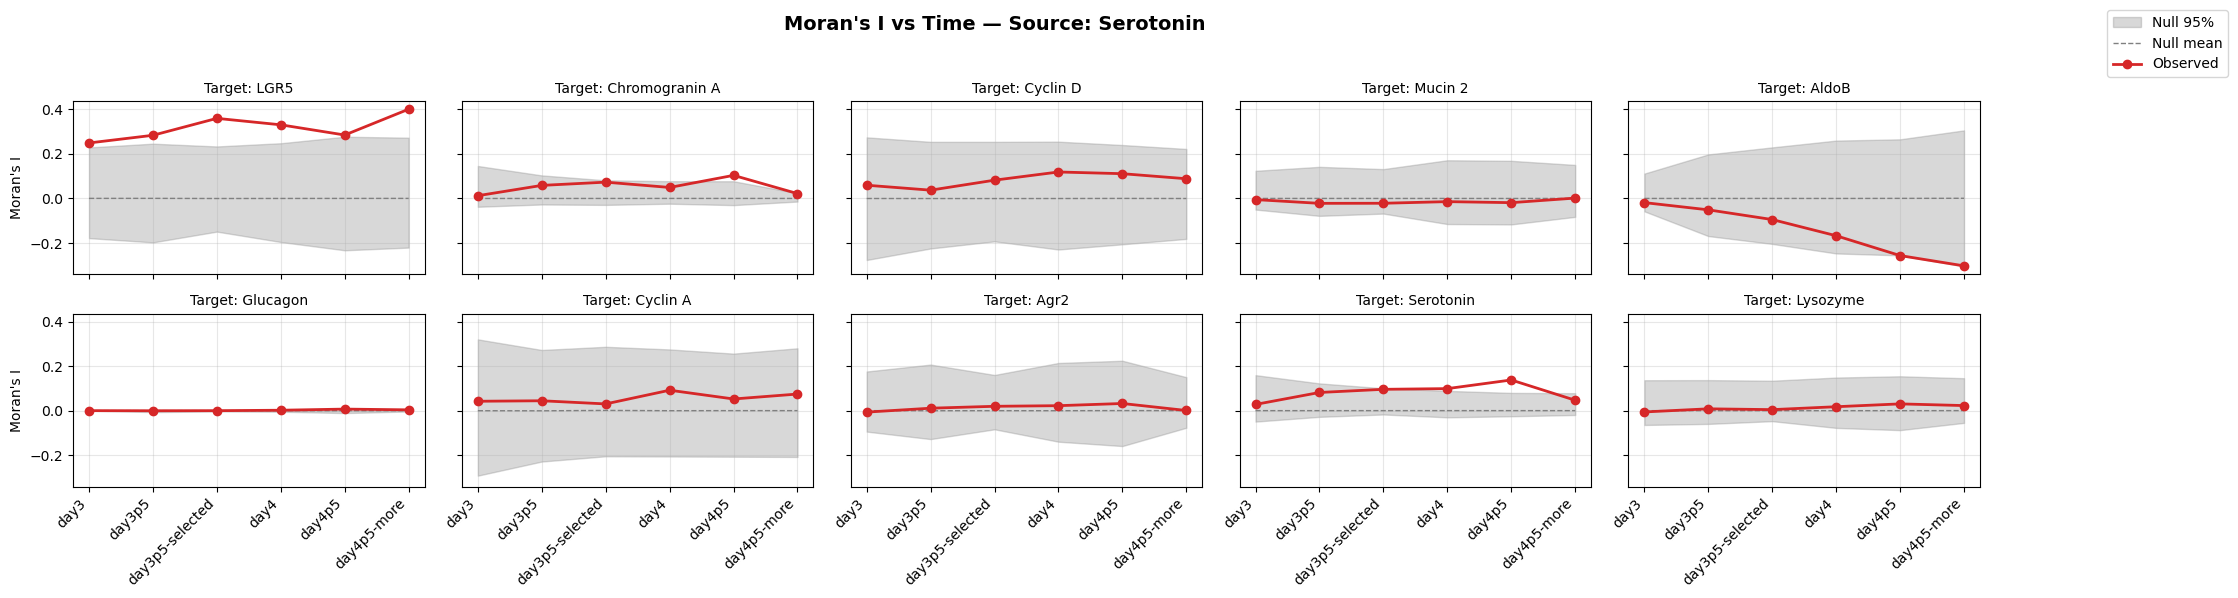

/tmp/ipykernel_11140/3878059829.py:90: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


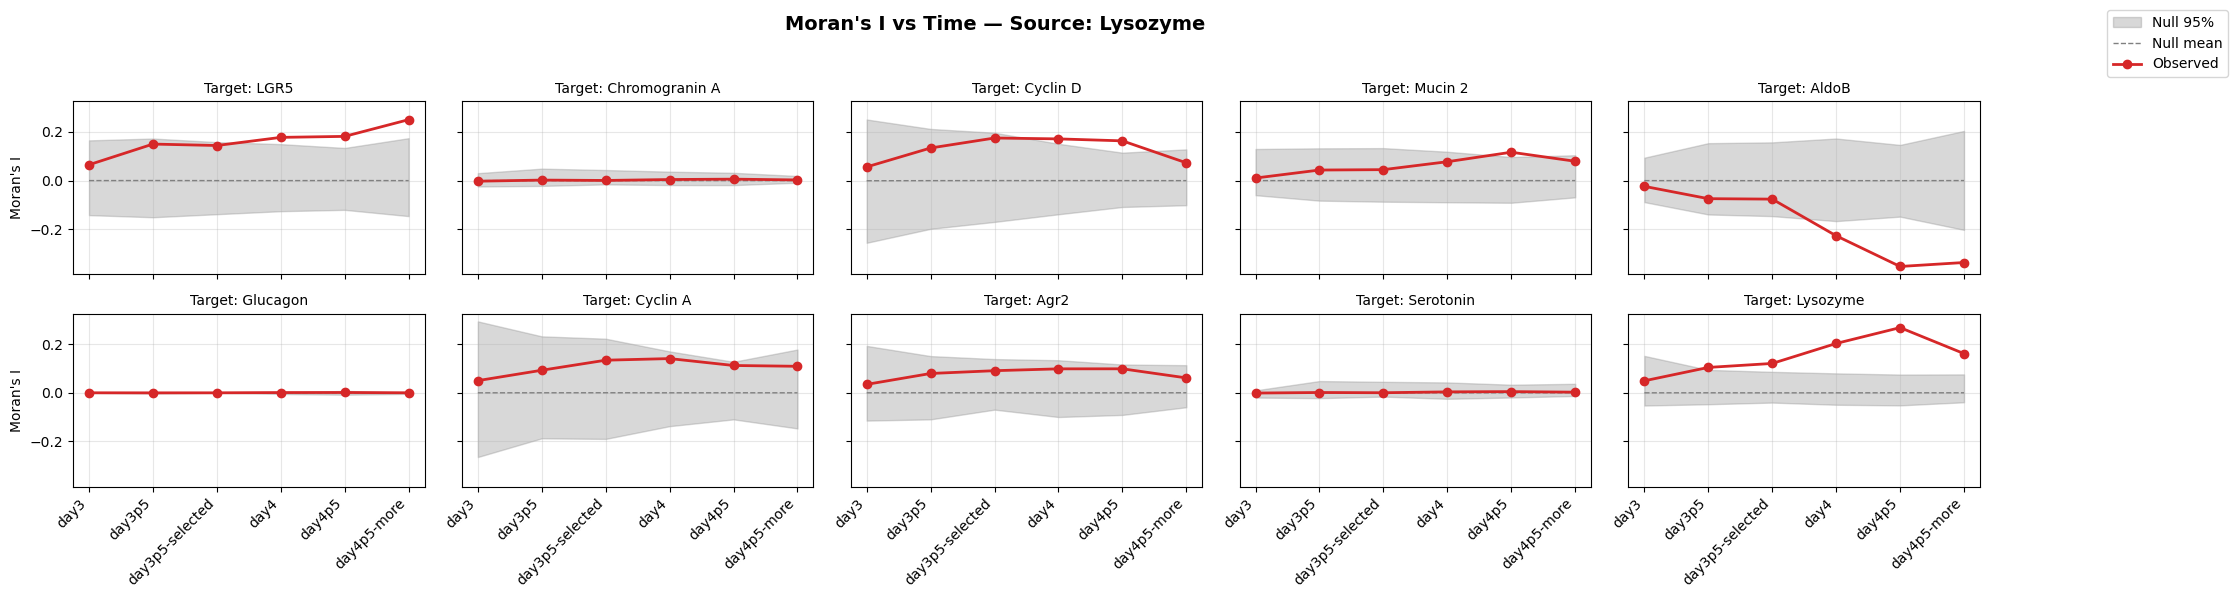

/tmp/ipykernel_11140/3878059829.py:90: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


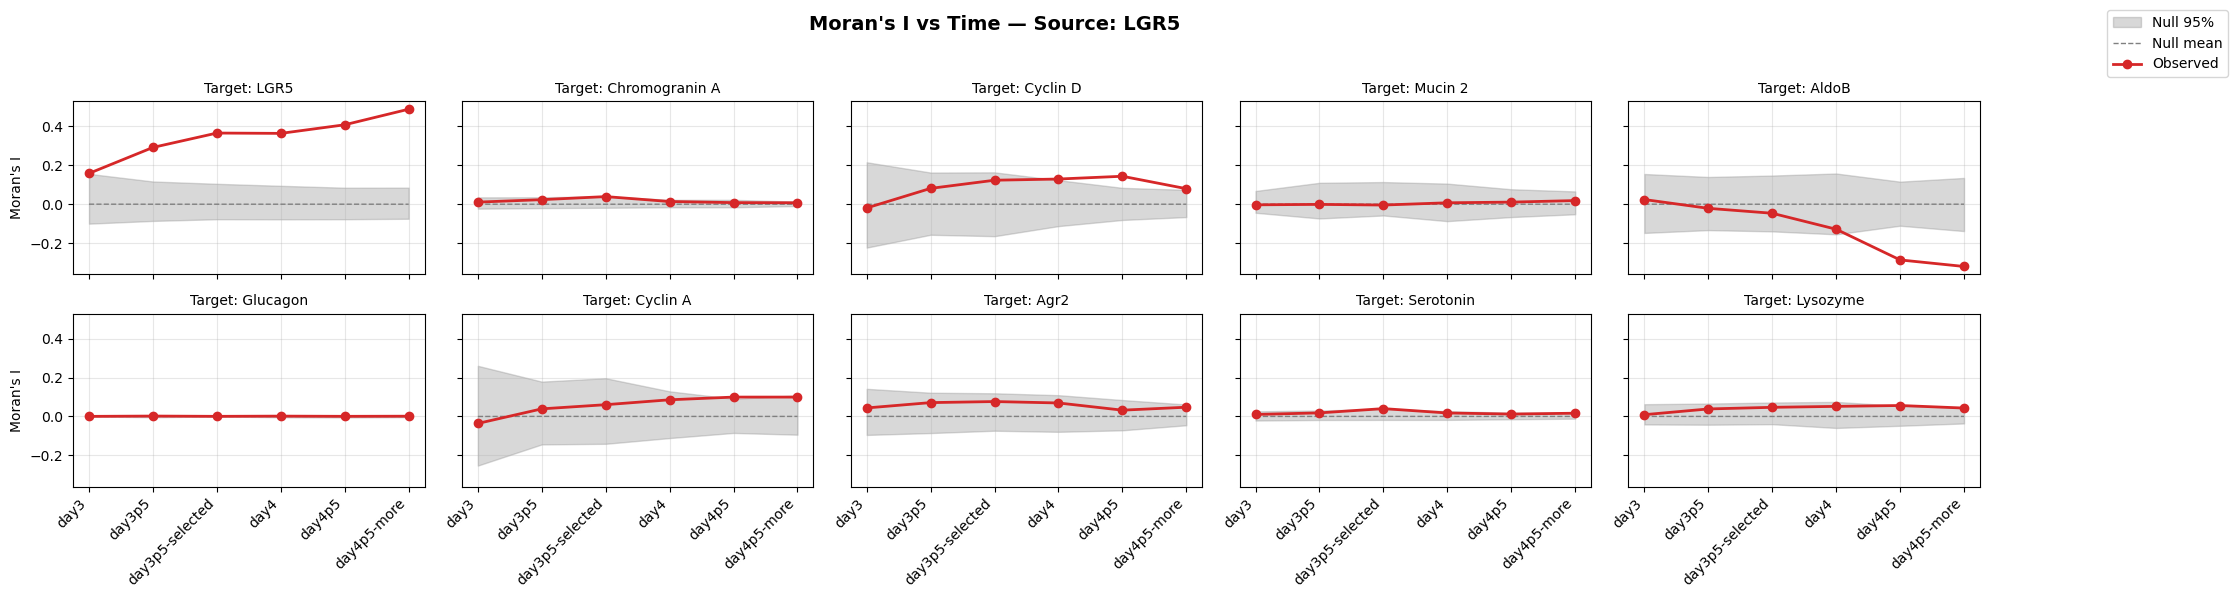

In [26]:
# Choose null envelope type
use_percentiles = True
lower_q, upper_q = 2.5, 97.5  # 95% CI if using percentiles
n_tp = len(timepoints)

# Determine layout for targets: 2 rows, ceil(n_markers / 2) columns
n_cols = int(np.ceil(n_markers / 2))
n_rows = 2

for i_source in source_indices:  # selected source markers only
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4 * n_cols, 3 * n_rows),
        sharex=True, sharey=True,
        constrained_layout=True
    )
    axes = axes.ravel()

    for j_target in range(n_markers):
        ax = axes[j_target]
        obs_means = []
        null_means = []
        null_lower = []
        null_upper = []

        for tp in timepoints:
            res = results[tp]
            I_obs = res["global_I_ensemble"][:, i_source, j_target]  # (n_org,)
            I_perm = res["global_perm_ensemble"][:, :, i_source, j_target]  # (n_org, n_perms)

            # Observed Moran's I (mean across organoids)
            obs_mean_tp = np.nanmean(I_obs)
            obs_means.append(obs_mean_tp)

            # Null distribution flattened
            I_perm_flat = I_perm.ravel()
            I_perm_flat = I_perm_flat[~np.isnan(I_perm_flat)]
            if I_perm_flat.size == 0:
                null_means.append(np.nan)
                null_lower.append(np.nan)
                null_upper.append(np.nan)
                continue

            null_means.append(np.mean(I_perm_flat))
            if use_percentiles:
                lower, upper = np.percentile(I_perm_flat, [lower_q, upper_q])
            else:
                mu, sigma = np.mean(I_perm_flat), np.std(I_perm_flat)
                lower, upper = mu - 2*sigma, mu + 2*sigma
            null_lower.append(lower)
            null_upper.append(upper)

        # Convert to arrays
        obs_means = np.array(obs_means)
        null_means = np.array(null_means)
        null_lower = np.array(null_lower)
        null_upper = np.array(null_upper)

        tp_indices = np.arange(n_tp)

        # Plot null envelope and observed Moran's I
        ax.fill_between(
            tp_indices,
            null_lower,
            null_upper,
            color='gray',
            alpha=0.3,
            label="Null 95%" if use_percentiles else "Null ±2σ"
        )
        ax.plot(tp_indices, null_means, color='gray', linestyle='--', lw=1, label="Null mean")
        ax.plot(tp_indices, obs_means, 'o-', color='tab:red', lw=2, label="Observed")

        ax.set_title(f"Target: {marker_names[j_target]}", fontsize=10)
        ax.set_xticks(tp_indices)
        ax.set_xticklabels(timepoints, rotation=45, ha='right')
        ax.grid(alpha=0.3)

        if j_target % n_cols == 0:
            ax.set_ylabel("Moran's I")

    # Turn off any unused axes if num markers is odd
    for ax in axes[n_markers:]:
        ax.axis('off')

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.12, 1.0))

    fig.suptitle(f"Moran's I vs Time — Source: {marker_names[i_source]}", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

/tmp/ipykernel_11140/3450029491.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')


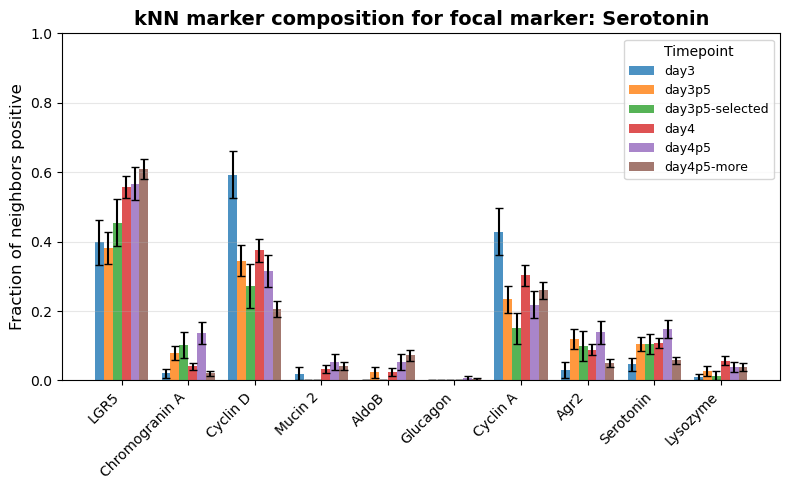

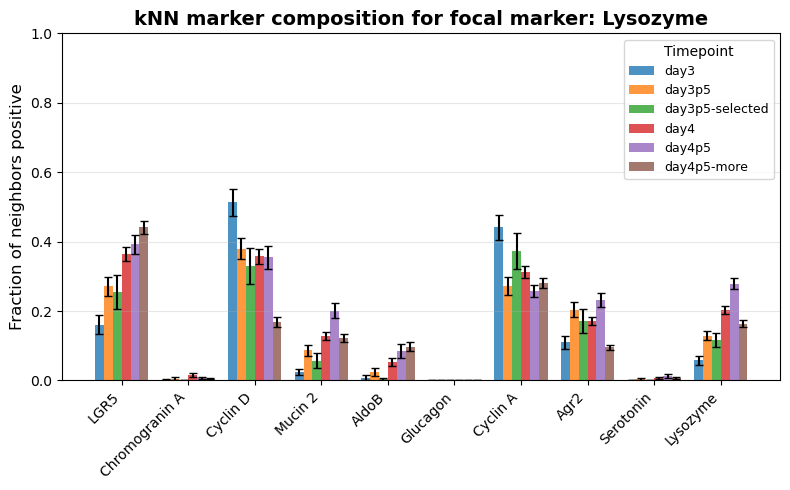

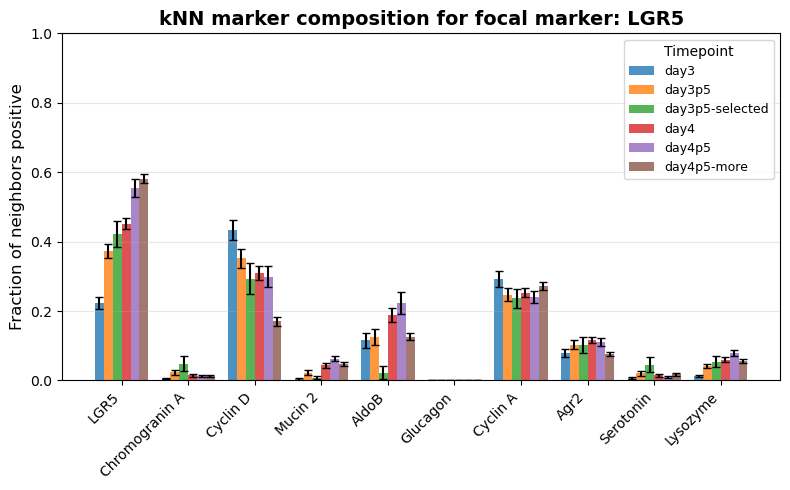

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# --- Colors for timepoints ---
cmap = get_cmap('tab10')
tp_colors = {tp: cmap(i % 10) for i, tp in enumerate(timepoints)}

# Indices of targeted source markers
target_source_indices = [
    marker_names.index(m)
    for m in target_source_markers
    if m in marker_names
]

# X positions for target markers
x = np.arange(len(marker_names))
bar_width = 0.8 / len(timepoints)  # narrower bars for grouping

for s_idx in target_source_indices:
    source_name = marker_names[s_idx]

    fig, ax = plt.subplots(
        figsize=(max(8, len(marker_names) * 0.8), 5)
    )

    for t_idx, tp in enumerate(timepoints):
        res = results[tp]

        # --- Extract data ---
        # shape (n_org, M, M)
        knn_avg_all = res['knn_avg_all']

        # Defensive check: skip if empty
        if knn_avg_all.size == 0:
            continue

        data_matrix = knn_avg_all[:, s_idx, :]  # shape (n_org, M)
        mean_vals = np.nanmean(data_matrix, axis=0)
        std_vals = np.nanstd(data_matrix, axis=0, ddof=1)
        n_vals = np.sum(~np.isnan(data_matrix), axis=0)
        sem_vals = np.where(n_vals > 1, std_vals / np.sqrt(n_vals), np.nan)

        # --- Bar positions offset for each timepoint ---
        x_offset = x + (t_idx - len(timepoints)/2) * bar_width + bar_width/2

        ax.bar(
            x_offset,
            mean_vals,
            yerr=sem_vals,
            capsize=3,
            width=bar_width,
            color=tp_colors[tp],
            alpha=0.8,
            label=tp
        )

    # --- Formatting ---
    ax.set_ylim(0, 1)

    ax.set_xticks(x)
    ax.set_xticklabels(marker_names, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel("Fraction of neighbors positive", fontsize=12)
    ax.set_title(f"kNN marker composition for focal marker: {source_name}",
                 fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    ax.legend(title="Timepoint", fontsize=9)
    plt.tight_layout()
    plt.show()

    # fig.savefig(f"kNN_composition_k3_{source_name}.pdf", bbox_inches='tight')


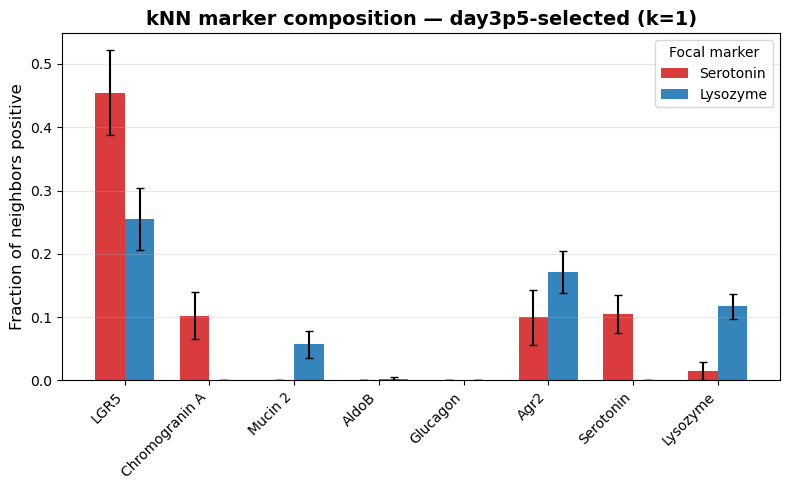

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# --- pick the timepoint robustly ---
tp_name = "day3p5-selected"
if tp_name not in results:
    # fallback to "third" key if name not present
    tp_name = list(results.keys())[2]
res = results[tp_name]

# --- focal markers & colors ---
focal_markers = ["Serotonin", "Lysozyme"]
focal_colors  = {"Serotonin": "tab:red", "Lysozyme": "tab:blue"}

# --- targets: exclude Cyclin A / Cyclin D ---
excluded_targets = {"Cyclin A", "Cyclin D"}
target_indices = [i for i, nm in enumerate(marker_names) if nm not in excluded_targets]
target_names   = [marker_names[i] for i in target_indices]

# --- indices of focal markers (skip if absent) ---
focal_indices = [marker_names.index(m) for m in focal_markers if m in marker_names]
focal_present = [marker_names[i] for i in focal_indices]
if len(focal_indices) == 0:
    raise ValueError("None of the focal markers found in marker_names")

# --- data: (n_org, M, M) ---
knn_avg_all = res["knn_avg_all"]
if knn_avg_all.size == 0:
    raise ValueError(f"No kNN data in results['{tp_name}']['knn_avg_all'].")

# --- plotting prep ---
n_targets = len(target_indices)
x = np.arange(n_targets)
bar_width = 0.35  # two bars per target

fig, ax = plt.subplots(figsize=(max(8, n_targets * 0.6), 5))

for f_idx, s_idx in enumerate(focal_indices):
    focal_name = marker_names[s_idx]

    # slice: (n_org, M) -> keep only desired targets
    data_matrix = knn_avg_all[:, s_idx, :][:, target_indices]  # (n_org, n_targets)

    mean_vals = np.nanmean(data_matrix, axis=0)
    std_vals  = np.nanstd(data_matrix, axis=0, ddof=1)
    n_vals    = np.sum(~np.isnan(data_matrix), axis=0)
    sem_vals  = np.where(n_vals > 1, std_vals / np.sqrt(n_vals), np.nan)

    # bar positions: side-by-side per target
    x_offset = x + (f_idx - len(focal_indices)/2) * bar_width + bar_width/2

    ax.bar(
        x_offset, mean_vals,
        yerr=sem_vals, capsize=3, width=bar_width,
        color=focal_colors.get(focal_name, None), alpha=0.9,
        label=focal_name
    )

# --- cosmetics ---
# ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(target_names, rotation=45, ha='right', fontsize=10)
ax.set_ylabel("Fraction of neighbors positive", fontsize=12)
ax.set_title(f"kNN marker composition — {tp_name} (k=1)", fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.legend(title="Focal marker", fontsize=10)

plt.tight_layout()
plt.savefig(f"kNN_composition_{tp_name}_Serotonin_Lysozyme_k1.pdf", bbox_inches='tight')


In [29]:
import pandas as pd
import numpy as np
import os

# --- pick timepoint ---
tp_name = "day3p5-selected"
if tp_name not in results:
    tp_name = list(results.keys())[2]
res = results[tp_name]

# --- focal markers & targets ---
focal_markers = ["Serotonin", "Lysozyme", "LGR5"]
excluded_targets = {"Cyclin A", "Cyclin D"}
target_indices = [i for i, nm in enumerate(marker_names) if nm not in excluded_targets]
target_names   = [marker_names[i] for i in target_indices]

focal_indices = [marker_names.index(m) for m in focal_markers if m in marker_names]
focal_present = [marker_names[i] for i in focal_indices]
if len(focal_indices) == 0:
    raise ValueError("None of the focal markers found in marker_names")

# --- knn data ---
knn_avg_all = res["knn_avg_all"]
if knn_avg_all.size == 0:
    raise ValueError(f"No kNN data in results['{tp_name}']['knn_avg_all'].")

# --- collect data into a list of dicts ---
rows = []
for f_idx, s_idx in enumerate(focal_indices):
    focal_name = marker_names[s_idx]

    data_matrix = knn_avg_all[:, s_idx, :][:, target_indices]  # (n_org, n_targets)
    mean_vals = np.nanmean(data_matrix, axis=0)
    std_vals  = np.nanstd(data_matrix, axis=0, ddof=1)
    n_vals    = np.sum(~np.isnan(data_matrix), axis=0)
    sem_vals  = np.where(n_vals > 1, std_vals / np.sqrt(n_vals), np.nan)

    for t_idx, target_name in enumerate(target_names):
        rows.append({
            "timepoint": tp_name,
            "focal_marker": focal_name,
            "target_marker": target_name,
            "mean_fraction_positive": mean_vals[t_idx],
            "sem_fraction_positive": sem_vals[t_idx],
            "n_organoids": int(n_vals[t_idx])
        })

# --- convert to DataFrame ---
df = pd.DataFrame(rows)

# --- save ---
# out_dir = "exports"
# os.makedirs(out_dir, exist_ok=True)
# csv_path = os.path.join(out_dir, f"kNN_composition_{tp_name}_Serotonin_Lysozyme.csv")
# df.to_csv(csv_path, index=False)
# print(f"✅ Exported data to {csv_path}")


/tmp/ipykernel_11140/1901378382.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')


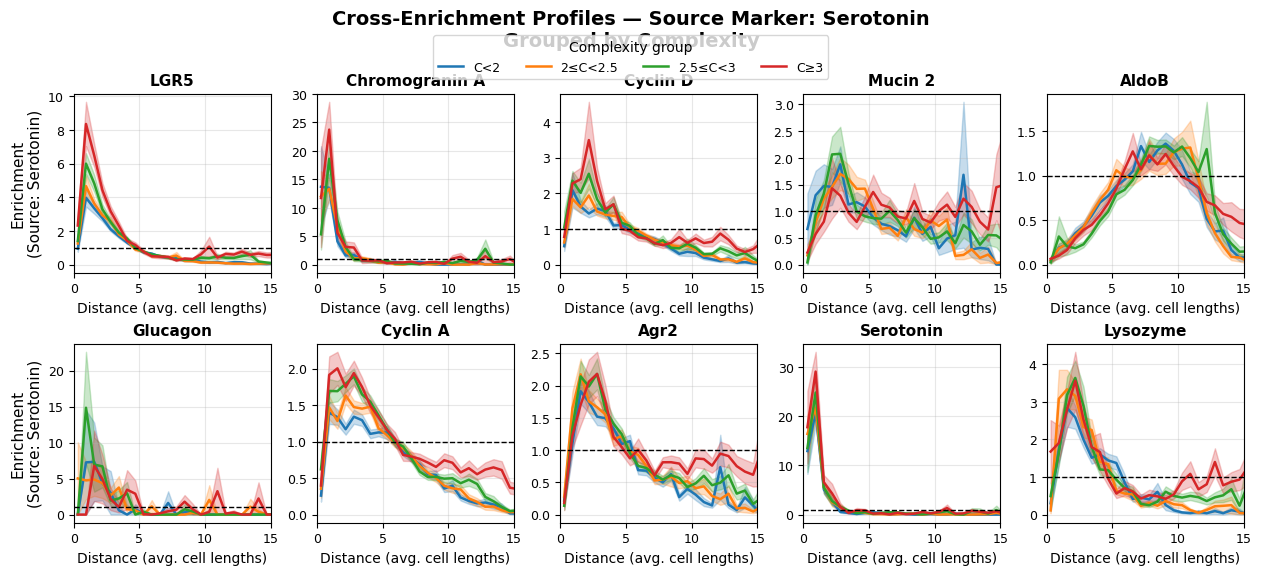

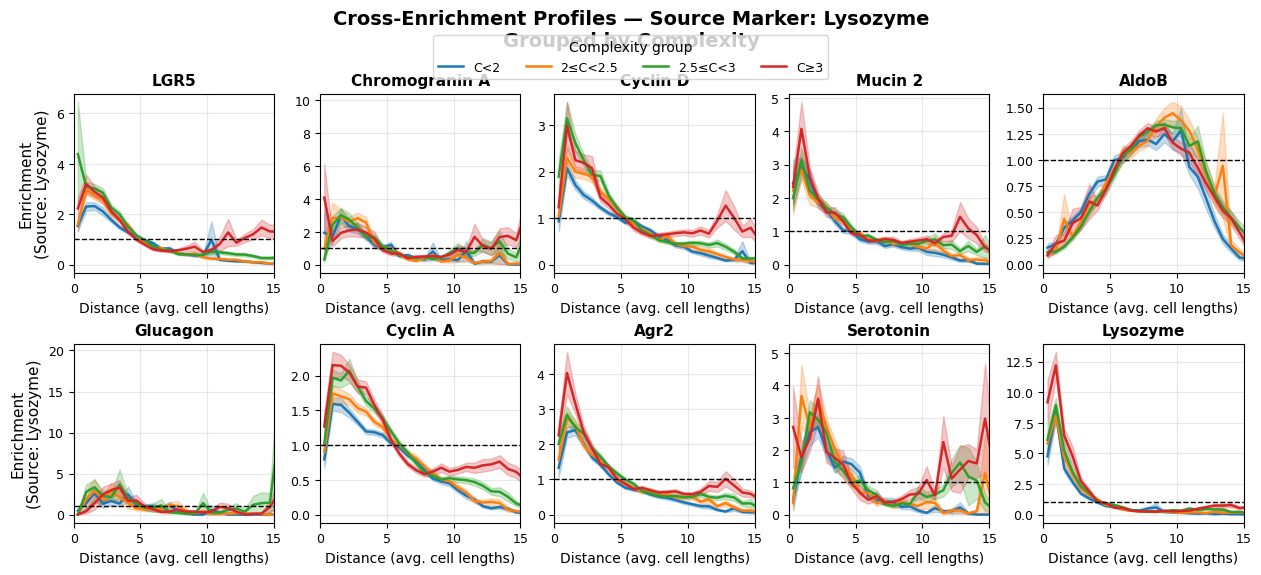

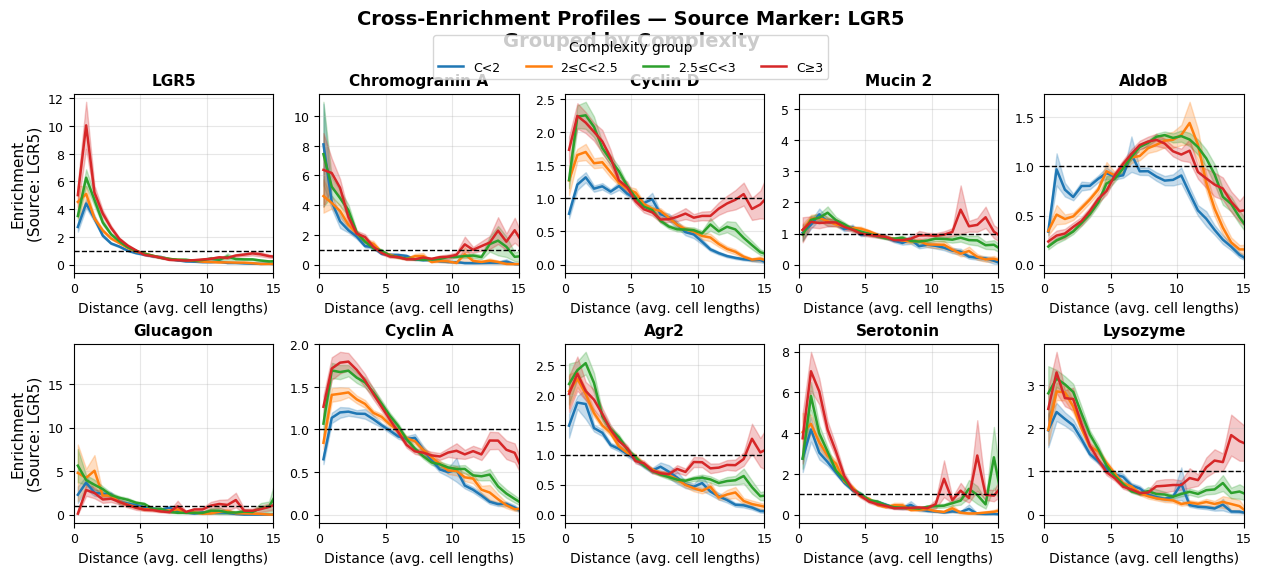

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# ------------------------------
# Setup
# ------------------------------
sample_tp = next(iter(results))
_, n_markers, nbins, _ = results[sample_tp]["Enrichment_all"].shape

# Define complexity bins
complexity_bins = [0, 2, 2.5, 3, np.inf]
# complexity_labels = ["C<2", "2≤C<3", "C≥3"]
complexity_labels = ["C<2", "2≤C<2.5", "2.5≤C<3","C≥3"]


# Colormap for complexity groups
cmap = get_cmap('tab10')
colors_complexity = {label: cmap(i % 10) for i, label in enumerate(complexity_labels)}

# ------------------------------
# Plot per SOURCE marker
# ------------------------------
n_cols = int(np.ceil(n_markers / 2))
n_rows = 2

for i_source in source_indices:
    source_name = marker_names[i_source]

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.5 * n_cols, 2.5 * n_rows),
        sharex=False, sharey=False,
        constrained_layout=True
    )
    axes = axes.ravel()

    for j_target in range(n_markers):
        ax = axes[j_target]

        # Loop over complexity groups
        for c_idx in range(len(complexity_bins)-1):
            c_low = complexity_bins[c_idx]
            c_high = complexity_bins[c_idx+1]
            c_label = complexity_labels[c_idx]
            c_color = colors_complexity[c_label]

            # Collect enrichment curves across *all timepoints* in this complexity bin
            group_curves = []
            for tp, res in results.items():
                complexities = np.asarray(res['complexity'])
                if complexities.size == 0:
                    continue

                n_org_curves = res['Enrichment_all'].shape[0]
                n_org_complexities = complexities.shape[0]

                # Make sure lengths match
                if n_org_complexities != n_org_curves:
                    n_min = min(n_org_complexities, n_org_curves)
                    complexities = complexities[:n_min]

                mask = (complexities >= c_low) & (complexities < c_high)
                if not np.any(mask):
                    continue

                enrichment_curves = res['Enrichment_all'][:len(complexities), i_source, :, j_target][mask]
                if enrichment_curves.size > 0:
                    group_curves.append(enrichment_curves)


            if len(group_curves) == 0:
                continue

            group_curves = np.concatenate(group_curves, axis=0)  # (n_org_total_in_bin, nbins)

            mean_curve = np.nanmean(group_curves, axis=0)
            std_curve  = np.nanstd(group_curves, axis=0, ddof=1)
            n_organoids = np.sum(~np.isnan(group_curves[:, 0]))
            sem_curve = std_curve / np.sqrt(n_organoids)

            ax.plot(
                bin_centers,
                mean_curve,
                color=c_color,
                lw=1.8,
                label=c_label
            )
            ax.fill_between(
                bin_centers,
                mean_curve - sem_curve,
                mean_curve + sem_curve,
                color=c_color,
                alpha=0.25
            )

        # --- Formatting ---
        ax.axhline(1.0, color='k', linestyle='--', linewidth=1)
        ax.set_xlim(0, 15)
        ax.set_title(marker_names[j_target], fontsize=11, fontweight='bold')
        ax.tick_params(axis='both', labelsize=9)
        ax.grid(alpha=0.3)

        ax.set_xlabel("Distance (avg. cell lengths)", fontsize=10)
        if j_target % n_cols == 0:
            ax.set_ylabel(f"Enrichment\n(Source: {source_name})", fontsize=11)

    # Turn off unused subplots if needed
    for j in range(n_markers, len(axes)):
        axes[j].axis('off')

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.08),
        ncol=len(complexity_labels),
        fontsize=9,
        title="Complexity group",
        title_fontsize=10
    )

    fig.suptitle(
        f"Cross-Enrichment Profiles — Source Marker: {source_name}\nGrouped by Complexity",
        fontsize=14, fontweight='bold', y=1.12
    )

    plt.show()
    # fig.savefig(f"enrichment_by_complexity_{source_name}.pdf", bbox_inches='tight')


/tmp/ipykernel_11140/1966456682.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')
/tmp/ipykernel_11140/1966456682.py:101: RuntimeWarning: Mean of empty slice
  mean_bin = np.nanmean(bin_profiles, axis=0)


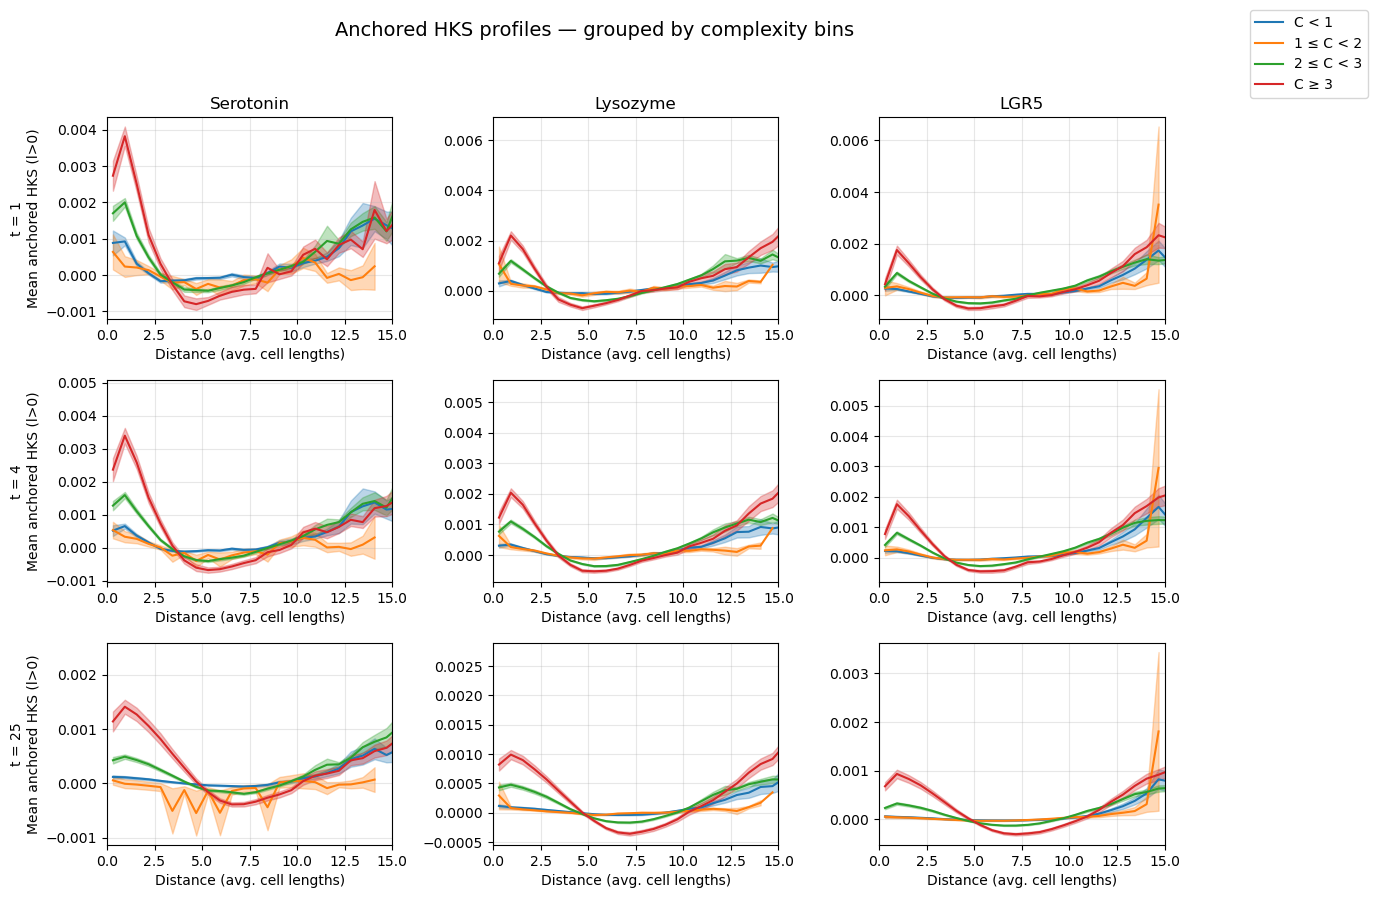

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Helper ---
def mean_sem_profiles(arr):
    """
    Compute mean and SEM across axis=0 for (n_org, n_markers, nbins, n_fields).
    Returns (mean, sem) with shape (n_markers, nbins, n_fields).
    """
    mean_profiles = np.nanmean(arr, axis=0)
    counts = np.sum(~np.isnan(arr), axis=0)
    std_profiles = np.nanstd(arr, axis=0, ddof=1)
    sem_profiles = np.where(counts > 1, std_profiles / np.sqrt(counts), np.nan)
    return mean_profiles, sem_profiles

# --- Complexity bins ---
complexity_bins = [
    (0, 2),
    (2, 2.5),
    (2.5, 3),
    (3, np.inf)
]
complexity_labels = ["C < 2", "2 ≤ C < 2.5", "2.5 ≤ C < 3", "C ≥ 3"]
cmap = get_cmap('tab10')
colors = [cmap(i) for i in range(len(complexity_bins))]

# --- Field labels ---
field_labels = ["t = 1", "t = 4", "t = 25"]
n_fields = len(field_labels)

# --- Determine marker indices to plot ---
target_indices = [
    marker_names.index(m) for m in target_source_markers if m in marker_names
]
n_targets = len(target_indices)
if n_targets == 0:
    raise ValueError("No target_source_markers found in marker_names!")

# Determine number of bins and fields
sample_tp = next(iter(results))
nbins = results[sample_tp]['hks_profile_all'].shape[2]
n_fields_detected = results[sample_tp]['hks_profile_all'].shape[3] if results[sample_tp]['hks_profile_all'].ndim == 4 else 1
assert n_fields_detected == n_fields, f"Expected {n_fields} fields, found {n_fields_detected}"

# ============================================================
# Plot by COMPLEXITY BIN (targeted markers × fields as rows)
# ============================================================
fig, axes = plt.subplots(
    n_fields, n_targets,
    figsize=(4 * n_targets, 3 * n_fields),
    sharex=False, sharey=False
)

if n_fields == 1:
    axes = axes[None, :]
if n_targets == 1:
    axes = axes[:, None]

legend_handles = []
legend_labels = []

for f_idx, field_label in enumerate(field_labels):
    for ax_idx, m_idx in enumerate(target_indices):
        ax = axes[f_idx, ax_idx]

        for c_idx, (c_low, c_high) in enumerate(complexity_bins):
            bin_profiles_list = []

            # Loop over timepoints and collect matching organoids
            for tp, res in results.items():
                if 'complexity' not in res:
                    continue

                complexities = np.asarray(res['complexity'])
                if complexities.size == 0:
                    continue

                n_org_curves = res['hks_profile_all'].shape[0]
                n_org_complexities = complexities.shape[0]

                # Length check
                if n_org_curves != n_org_complexities:
                    n_min = min(n_org_curves, n_org_complexities)
                    complexities = complexities[:n_min]

                mask = (complexities >= c_low) & (complexities < c_high)
                if not np.any(mask):
                    continue

                # Select profiles for this marker, field and bin
                profiles_tp = res['hks_profile_all'][:len(complexities), m_idx, :, f_idx]
                selected_profiles = profiles_tp[mask]
                if selected_profiles.size > 0:
                    bin_profiles_list.append(selected_profiles)

            if len(bin_profiles_list) == 0:
                continue

            # Concatenate across all timepoints for this complexity bin
            bin_profiles = np.vstack(bin_profiles_list)
            mean_bin = np.nanmean(bin_profiles, axis=0)
            sem_bin = np.nanstd(bin_profiles, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(bin_profiles), axis=0))

            line, = ax.plot(bin_centers, mean_bin, '-', color=colors[c_idx], label=complexity_labels[c_idx])
            ax.fill_between(
                bin_centers,
                mean_bin - sem_bin,
                mean_bin + sem_bin,
                color=colors[c_idx],
                alpha=0.3
            )

            if complexity_labels[c_idx] not in legend_labels:
                legend_handles.append(line)
                legend_labels.append(complexity_labels[c_idx])

        if f_idx == 0:
            ax.set_title(marker_names[m_idx])
        if ax_idx == 0:
            ax.set_ylabel(f"{field_label}\nMean anchored HKS (l>0)")
        ax.set_xlabel("Distance (avg. cell lengths)")
        ax.grid(True, alpha=0.3)
        ax.set_xlim((0, 15))
        # ax.set_ylim((-1e-3, 8e-3))

fig.suptitle("Anchored HKS profiles — grouped by complexity bins", fontsize=14)
fig.legend(legend_handles, legend_labels, loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# fig.savefig("anchored_HKS_profiles_by_complexity_all_fields.pdf", bbox_inches='tight')
